In [ ]:
# Carl et al. (in review): data analysis script
# Copyright (C) 2025 Friedrich Carl
# This file is part of Carl et al. (in review).
#
# The code is free software: you can redistribute it and/or modify
# it under the terms of the GNU General Public License as published by
# the Free Software Foundation, either version 3 of the License, or
# (at your option) any later version.
#
# The code is distributed in the hope that it will be useful,
# but WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
# GNU General Public License for more details.
#
# You should have received a copy of the GNU General Public License
# along with MyProject.  If not, see  https://www.gnu.org/licenses/gpl-3.0.txt.

In [ ]:
"""This is the code for the data analysis described in Carl et al. (in prep., 2026). This script processes the raw dimensional data generated 
with the "measurement script", generates histograms & CDF´s, computes statistical moments, processes gradients (generation of histograms), 
computes the (mean) averaged Kullback-Leibler divergences and the (mean) PC space distances
For descriptions and additional information, please refer to the paper.
Please remember to adjust file paths and directories to your system"""

In [1]:
"""Step 1 of processing the raw dimensional data: combining measurements of both horizontal directions & vertical data 
of a specific input structure into a single combined file ("master file") per horizontal direction"""


"""Step 1 of processing the raw dimensional data"""

import os
import re
import pandas as pd

# Base directory containing all datasets
base_raw_data_dir = (
    r"C:\Users\carl\Desktop\Paper 3\random datasets standard models"
    r"\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Raw data"
)

# Output directory
output_dir = (
    r"C:\Users\carl\Desktop\Paper 3\random datasets standard models"
    r"\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Auswertungen\intermediate"
)

# Function to extract numeric part from filename
def extract_numeric_part(filename):
    match = re.search(r'\d+', filename)
    if match:
        return int(match.group())
    else:
        return float('inf')

# Iterate over all dataset directories
for dataset_name in os.listdir(base_raw_data_dir):

    dataset_path = os.path.join(base_raw_data_dir, dataset_name)

    if not os.path.isdir(dataset_path):
        continue

    print(f"Processing dataset: {dataset_name}")

    # =========================
    # FIRST DIRECTION
    # =========================

    directory = os.path.join(dataset_path, "1st direction")
    master_df = pd.DataFrame()

    if os.path.isdir(directory):
        files = sorted(os.listdir(directory), key=extract_numeric_part)

        for filename in files:
            if filename.endswith('.csv'):
                file_path = os.path.join(directory, filename)
                df = pd.read_csv(file_path, delimiter=',')
                extracted_df = df[['Horizontal Length', 'Vertical Length']]
                master_df = pd.concat([master_df, extracted_df], ignore_index=True)

        if not master_df.empty:
            master_file_path = os.path.join(
                output_dir,
                f"{dataset_name}_Auswertung_direction 1.xlsx"
            )
            master_df.to_excel(master_file_path, index=False)
            print(f"Master file created: {master_file_path}")
        else:
            print(f"No data found for 1st direction in {dataset_name}")

    else:
        print(f"Missing 1st direction folder in {dataset_name}")

    # =========================
    # SECOND (ORTHOGONAL) DIRECTION
    # =========================

    directory = os.path.join(dataset_path, "2nd direction")
    master_df = pd.DataFrame()

    if os.path.isdir(directory):
        files = sorted(os.listdir(directory), key=extract_numeric_part)

        for filename in files:
            if filename.endswith('.csv'):
                file_path = os.path.join(directory, filename)
                df = pd.read_csv(file_path, delimiter=',')
                extracted_df = df[['Horizontal Length', 'Vertical Length']]
                extracted_df.columns = ['Horizontal Length Orthogonal', 'Vertical Length']
                master_df = pd.concat([master_df, extracted_df], ignore_index=True)

        master_file_path = os.path.join(
            output_dir,
            f"{dataset_name}_Auswertung_direction 2.xlsx"
        )
        master_df.to_excel(master_file_path, index=False)
        print(f"Master file created: {master_file_path}")

    else:
        print(f"Missing 2nd direction folder in {dataset_name}")



Processing dataset: 0 sections 10 boreholes_hull_GE_101_smoothed
Master file created: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Structural dimensions\Auswertungen\intermediate\0 sections 10 boreholes_hull_GE_101_smoothed_Auswertung_direction 1.xlsx
Master file created: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Structural dimensions\Auswertungen\intermediate\0 sections 10 boreholes_hull_GE_101_smoothed_Auswertung_direction 2.xlsx
Processing dataset: 0 sections 10 boreholes_hull_GE_125_smoothed
Master file created: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Structural dimensions\Auswertungen\intermediate\0 sections 10 boreholes_hull_GE_125_smoothed_Auswertung_direction 1.xlsx
Master file created: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Structural dimensions\Auswertungen\intermediate\0 sections 10 boreholes_hull_GE_125_smoothed_Auswertung_direction 2.xlsx
Processing dataset: 0 sect

In [2]:
"""Step 2: combining both master files into a single file"""
import os
import pandas as pd

# Base directory containing all dataset folders (same as used before)
base_raw_data_dir = (
    r"C:\Users\carl\Desktop\Paper 3\random datasets standard models"
    r"\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Raw data"
)

# Directory where the intermediate master files were written in the previous step
intermediate_dir = (
    r"C:\Users\carl\Desktop\Paper 3\random datasets standard models"
    r"\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Auswertungen\intermediate"
)

# Directory where combined datasets will be saved
combined_output_dir = (
    r"C:\Users\carl\Desktop\Paper 3\random datasets standard models"
    r"\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Auswertungen\Datensätze"
)
os.makedirs(combined_output_dir, exist_ok=True)

# Iterate through every dataset folder found in the raw data directory
for dataset_name in os.listdir(base_raw_data_dir):
    dataset_path = os.path.join(base_raw_data_dir, dataset_name)
    if not os.path.isdir(dataset_path):
        continue  # skip non-directories

    print(f"\nProcessing combined dataset for: {dataset_name}")

    
    file_1st_direction = os.path.join(
        intermediate_dir, f"{dataset_name}_Auswertung_direction 1.xlsx"
    )
    file_2nd_direction = os.path.join(
        intermediate_dir, f"{dataset_name}_Auswertung_direction 2.xlsx"
    )

    # Check both files exist
    if not os.path.exists(file_1st_direction):
        print(f"  Missing file: {file_1st_direction}  → skipping this dataset")
        continue
    if not os.path.exists(file_2nd_direction):
        print(f"  Missing file: {file_2nd_direction}  → skipping this dataset")
        continue

    try:
        # Read the two intermediate master files
        df_1st_direction = pd.read_excel(file_1st_direction)
        df_2nd_direction = pd.read_excel(file_2nd_direction)
    except Exception as e:
        print(f"  Error reading files for {dataset_name}: {e}")
        continue

    # Make sure required columns exist; if not, print and skip
    required_cols_1 = ['Horizontal Length', 'Vertical Length']
    required_cols_2 = ['Horizontal Length Orthogonal', 'Vertical Length']
    if not all(col in df_1st_direction.columns for col in required_cols_1):
        print(f"  Missing required columns in {file_1st_direction}: {df_1st_direction.columns.tolist()}")
        continue
    if not all(col in df_2nd_direction.columns for col in required_cols_2):
        print(f"  Missing required columns in {file_2nd_direction}: {df_2nd_direction.columns.tolist()}")
        continue

    # Concatenate Vertical Length columns from both directions into one column
    Vertical_Length_combined = pd.concat(
        [df_1st_direction['Vertical Length'], df_2nd_direction['Vertical Length']],
        ignore_index=True
    )

    # Build the combined master DataFrame
    master_df = pd.DataFrame({
        'Horizontal Length': df_1st_direction['Horizontal Length'],
        'Vertical Length': Vertical_Length_combined,
        'Horizontal Length Orthogonal': df_2nd_direction['Horizontal Length Orthogonal']
    })

    master_combined_file_path = os.path.join(
        combined_output_dir, f"{dataset_name}_Datensatz.xlsx"
    )

    try:
        master_df.to_excel(master_combined_file_path, index=False)
        print(f"  Combined master file created at: {master_combined_file_path}")
    except Exception as e:
        print(f"  Failed to save combined file for {dataset_name}: {e}")




Processing combined dataset for: 0 sections 10 boreholes_hull_GE_101_smoothed
  Combined master file created at: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Structural dimensions\Auswertungen\Datensätze\0 sections 10 boreholes_hull_GE_101_smoothed_Datensatz.xlsx

Processing combined dataset for: 0 sections 10 boreholes_hull_GE_125_smoothed
  Combined master file created at: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Structural dimensions\Auswertungen\Datensätze\0 sections 10 boreholes_hull_GE_125_smoothed_Datensatz.xlsx

Processing combined dataset for: 0 sections 10 boreholes_hull_GE_150_smoothed
  Combined master file created at: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Structural dimensions\Auswertungen\Datensätze\0 sections 10 boreholes_hull_GE_150_smoothed_Datensatz.xlsx

Processing combined dataset for: 0 sections 10 boreholes_hull_GE_175_smoothed
  Combined master file created at: C:\Users\carl\Deskt

In [3]:
"""Step 3: Creation of the fourth parameter being the combined horizontal extents; 
computation of statistical moments and other parameters; creation of histograms and CDF´s
The code iterates through all dataset folders in the Raw data directory.
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew
from matplotlib.ticker import PercentFormatter
from scipy.stats import entropy
import xlsxwriter

# Base directory that contains all dataset folders (same as previous steps)
base_raw_data_dir = (
    r"C:\Users\carl\Desktop\Paper 3\random datasets standard models"
    r"\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Raw data"
)

# Directory where combined datasets are stored (from previous step)
combined_dir = (
    r"C:\Users\carl\Desktop\Paper 3\random datasets standard models"
    r"\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Auswertungen\Datensätze"
)

# Directory where per-dataset statistics & histograms will be saved
stats_output_base = (
    r"C:\Users\carl\Desktop\Paper 3\random datasets standard models"
    r"\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Auswertungen\statistics and histograms"
)
os.makedirs(stats_output_base, exist_ok=True)


columns = ['Horizontal Length', 'Vertical Length', 'Horizontal Length Orthogonal']

# Global results dict is defined here but will be reset per dataset inside the loop
results = {}

# Function to compute and plot statistics 
def analyze_column(data, column_name, bins):
    stats = {}
    stats['mean'] = np.mean(data)
    stats['variance'] = np.var(data)
    stats['std_dev'] = np.std(data)
    stats['skewness'] = skew(data)
    stats['median'] = np.median(data)

    # compute entropy
    counts, bin_edges = np.histogram(data, bins=bins, density=False)
    probabilities = counts / counts.sum()  # Normalize to get probabilities
    stats['entropy'] = entropy(probabilities, base=2)  # Calculate entropy in bits

    # Store the computed statistics in the (global) results dict
    results[column_name] = stats

    # Plot histogram
    fig, ax1 = plt.subplots()

    # Plot histogram
    ax1.hist(data, bins=bins, alpha=0.7, color='blue', edgecolor='black')

    # Plot CDF
    ax2 = ax1.twinx()
    cdf = np.cumsum(counts)
    cdf = cdf / cdf[-1]  # Normalize to [0, 1]
    ax2.plot(bin_edges[1:], cdf, color='red', marker='o', linestyle='-', linewidth=1.5, markersize=4)
    ax2.set_ylim(0, 1)
    ax2.yaxis.set_major_formatter(PercentFormatter(1))

    # Set labels and title
    ax1.set_xlabel(f'{column_name} [m]')
    ax1.set_ylabel('Frequency')
    ax2.set_ylabel('CDF')
    plt.title(f'Histogram and CDF of {column_name}')

    # Adjust layout to prevent cropping
    plt.tight_layout()

    # Return the figure object so the caller can save it where it wants
    return fig

# Function to load measurement data 
def load_measurement_data(directory):
    data = []
    if not os.path.isdir(directory):
        return data
    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            filepath = os.path.join(directory, filename)
            df_local = pd.read_csv(filepath)
            data.append(df_local)
    return data

# Iterate through all dataset folders in the Raw data directory
for dataset_name in os.listdir(base_raw_data_dir):
    dataset_path = os.path.join(base_raw_data_dir, dataset_name)
    if not os.path.isdir(dataset_path):
        continue

    print(f"\nProcessing dataset: {dataset_name}")

   
    combined_file = os.path.join(combined_dir, f"{dataset_name}_Datensatz.xlsx")
    if not os.path.exists(combined_file):
        print(f"  Combined dataset file not found: {combined_file}  → skipping")
        continue

    # Read the combined dataset
    try:
        df = pd.read_excel(combined_file)
    except Exception as e:
        print(f"  Failed to read combined file for {dataset_name}: {e}")
        continue

    # Reset results dict for this dataset
    results = {}

    # Create per-dataset temporary plot dir
    plot_dir = os.path.join(stats_output_base, f"plots_{dataset_name}")
    os.makedirs(plot_dir, exist_ok=True)

    # Analyze each specified column
    bins = 14
    for column in columns:
        # Guard against missing column
        if column not in df.columns:
            print(f"  Warning: column '{column}' not in {combined_file}; skipping this column.")
            continue
        data = df[column].dropna()
        if data.empty:
            print(f"  Column '{column}' has no data for {dataset_name}; skipping.")
            continue

        fig = analyze_column(data, column, bins)
        # Save the plot to the per-dataset plot directory
        plot_path = os.path.join(plot_dir, f"{column}.png")
        fig.savefig(plot_path)
        plt.close(fig)

    # Combined horizontal data
    if 'Horizontal Length' in df.columns and 'Horizontal Length Orthogonal' in df.columns:
        combined_data = pd.concat([df['Horizontal Length'].dropna(), df['Horizontal Length Orthogonal'].dropna()])
        fig = analyze_column(combined_data, 'Horizontal data combined', bins=bins)
        plot_path = os.path.join(plot_dir, 'Horizontal data combined.png')
        fig.savefig(plot_path)
        plt.close(fig)
    else:
        print("  Warning: Horizontal Length or Horizontal Length Orthogonal missing; skipping combined horizontal analysis.")

    # Load raw measurement data folders
    dir_1st = os.path.join(dataset_path, "1st direction")
    dir_2nd = os.path.join(dataset_path, "2nd direction")

    data_1st = load_measurement_data(dir_1st)
    data_2nd = load_measurement_data(dir_2nd)

    # Save results and images to an Excel file for this dataset
    output_file_path = os.path.join(stats_output_base, f"{dataset_name}_Auswertung.xlsx")
    try:
        with pd.ExcelWriter(output_file_path, engine='xlsxwriter') as writer:
            # Save the combined data (original df)
            df.to_excel(writer, sheet_name='Data', index=False)

            # Convert results dict to DataFrame and save
            results_df = pd.DataFrame(results).T  # Transpose for readability
            results_df.to_excel(writer, sheet_name='Statistics')

            # Prepare workbook/worksheet for histograms
            workbook = writer.book
            worksheet = workbook.add_worksheet('Histograms')
            writer.sheets['Histograms'] = worksheet

            # Insert images into the worksheet
            row = 0
            for column in [c for c in columns if c in df.columns] + ['Horizontal data combined']:
                plot_path = os.path.join(plot_dir, f"{column}.png")
                if os.path.exists(plot_path):
                    worksheet.insert_image(row, 0, plot_path)
                    row += 15  # Adjust the row number for the next image (keeps your original number)
                else:
                    print(f"  Warning: Image file '{plot_path}' not found for {dataset_name}.")

        print(f"  Statistics and histograms saved to: {output_file_path}")

    except Exception as e:
        print(f"  Failed to write Excel for {dataset_name}: {e}")

    # Clean up temporary plot directory
    try:
        for plot_file in os.listdir(plot_dir):
            os.remove(os.path.join(plot_dir, plot_file))
        os.rmdir(plot_dir)
    except Exception as e:
        print(f"  Warning: could not fully remove plot directory {plot_dir}: {e}")

    # Print computed statistics for quick console feedback
    for column_key, stats in results.items():
        print(f"  Statistics for {column_key}:")
        print(f"    Mean: {stats['mean']}")
        print(f"    Median: {stats['median']}")
        print(f"    Variance: {stats['variance']}")
        print(f"    Standard Deviation: {stats['std_dev']}")
        print(f"    Skewness: {stats['skewness']}\n")

print("\nAll datasets processed (where combined files were present).")





Processing dataset: 0 sections 10 boreholes_hull_GE_101_smoothed
  Statistics and histograms saved to: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Structural dimensions\Auswertungen\statistics and histograms\0 sections 10 boreholes_hull_GE_101_smoothed_Auswertung.xlsx
  Statistics for Horizontal Length:
    Mean: 2438.103269117844
    Median: 2464.773241734132
    Variance: 248908.5513192687
    Standard Deviation: 498.90735745153
    Skewness: -0.46010697927026506

  Statistics for Vertical Length:
    Mean: 2490.5800101117034
    Median: 2695.1699425589964
    Variance: 287333.27612316626
    Standard Deviation: 536.0347713751098
    Skewness: -1.6788445079273888

  Statistics for Horizontal Length Orthogonal:
    Mean: 3711.550373091406
    Median: 3338.137653592305
    Variance: 1200700.7565950353
    Standard Deviation: 1095.764918490748
    Skewness: 0.5391649509673164

  Statistics for Horizontal data combined:
    Mean: 3074.8268211046247
    Median: 2

In [4]:
"""averaged statistics for the statistics-parameter pairs (see below) of all datasets in case it is of interest"""

import os
import pandas as pd

# taken from the data analysis output file also containing the histograms
directory_path = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Auswertungen\statistics and histograms"


# Define the list of parameters
parameters = ["Horizontal Length", "Vertical Length", "Horizontal Length Orthogonal", "Horizontal data combined"]

# Define the statistics
statistics = ["mean", "variance", "std_dev", "skewness", "median"]

# Dictionary to store aggregated statistics for each parameter-statistic pair
aggregated_statistics = {stat: {param: [] for param in parameters} for stat in statistics}

# Process each file in the directory
for file_name in os.listdir(directory_path):
    
    file_path = os.path.join(directory_path, file_name)

    # Read the second sheet ("statistics") of the current Excel file
    try:
        df = pd.read_excel(file_path, sheet_name="Statistics", header=0, index_col=0)
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")
        continue

    # Extract statistics for the defined parameters
    for parameter in parameters:
        if parameter in df.index:
            for stat in statistics:
                value = df.loc[parameter, stat]
                aggregated_statistics[stat][parameter].append(value)

# Calculate the arithmetic mean for each parameter-statistic pair
mean_statistics = {
    stat: {param: sum(values) / len(values) if values else None
           for param, values in param_values.items()}
    for stat, param_values in aggregated_statistics.items()
}

# Convert the result to a DataFrame for easier visualization
mean_statistics_df = pd.DataFrame(mean_statistics)

# Print the resulting DataFrame
print("Arithmetic Mean of Parameter-Statistic Pairs Across Files:")
print(mean_statistics_df)

# Optionally, save the results to an Excel file
output_path = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Auswertungen\parameter_statistics_means.xlsx"
mean_statistics_df.to_excel(output_path, index_label="Parameter")
print(f"Results saved to {output_path}")


Arithmetic Mean of Parameter-Statistic Pairs Across Files:
                                     mean      variance      std_dev  \
Horizontal Length             1606.309604  2.594022e+05   500.851133   
Vertical Length               1767.064945  3.544049e+05   558.732342   
Horizontal Length Orthogonal  2818.481165  1.015546e+06   970.718304   
Horizontal data combined      2212.395385  1.047428e+06  1000.853447   

                              skewness       median  
Horizontal Length            -0.217863  1635.821891  
Vertical Length              -0.689051  1761.388345  
Horizontal Length Orthogonal -0.965657  3018.404402  
Horizontal data combined      0.147951  2104.306757  
Results saved to C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Structural dimensions\Auswertungen\parameter_statistics_means.xlsx


In [5]:
""" Processing of gradient data """
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openpyxl.drawing.image import Image

# ─── CONFIG ────────────────────────────────────────────────────────────────────
input_dir  = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Grad\Raw data"
output_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Grad\Gradient Auswertung"

os.makedirs(output_dir, exist_ok=True)
plot_dir = "plots"
os.makedirs(plot_dir, exist_ok=True)

# ─── PROCESS ONE FILE ───────────────────────────────────────────────────────────
def process_file(file_path):
    name = os.path.splitext(os.path.basename(file_path))[0]
    
    df = pd.read_csv(
        file_path)
    
    grads = df["Gradients"].values
    
    finite_g = grads[np.isfinite(grads)]
    inf_count = np.sum(~np.isfinite(grads))
    
    # split into pos/neg
    pos = finite_g[finite_g > 0]
    neg = finite_g[finite_g < 0]
    
    use_overflow = (pos.size > 0 and neg.size > 0)
    
    grad_img = None
    
    # ─ Overflow bin logic ─────────────────────────────
    if use_overflow:
        th_p = np.percentile(pos, 95)
        th_n = np.percentile(neg, 5)
        
        g_b = np.clip(finite_g, th_n, th_p)
        
        plt.figure()
        plt.hist(g_b, bins=30, alpha=0.7, edgecolor="black", label="Binned Gradients")
        plt.axvline(th_p, linestyle="--", label=f"+95th pct = {th_p:.1f}")
        plt.axvline(th_n, linestyle="--", label=f"-5th pct = {th_n:.1f}")
        plt.axhline(inf_count, linestyle="--", label=f"inf count = {inf_count}")
        plt.xlabel("Gradient Value")
        plt.ylabel("Frequency")
        plt.title(f"{name}: Gradients w/ overflow bins")
        plt.legend()
        
        grad_img = os.path.join(plot_dir, f"{name}_grad_overflow.png")
        plt.tight_layout()
        plt.savefig(grad_img, dpi=360)
        plt.close()
    
    # ─ Simple histogram ───────────────────────────────
    else:
        plt.figure()
        plt.hist(finite_g, bins=30, alpha=0.7, edgecolor="black", label="Finite Gradients")
        plt.axhline(inf_count, linestyle="--", label=f"inf count = {inf_count}")
        plt.xlabel("Gradient Value")
        plt.ylabel("Frequency")
        plt.title(f"{name}: Gradients (no overflow)")
        plt.legend()
        
        grad_img = os.path.join(plot_dir, f"{name}_grad_simple.png")
        plt.tight_layout()
        plt.savefig(grad_img, dpi=360)
        plt.close()
    
    # ─── WRITE EXCEL ─────────────────────────────────────────────
    out_xlsx = os.path.join(output_dir, f"{name}.xlsx")
    
    with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
        df.to_excel(writer, sheet_name="Data", index=False)
        wb = writer.book
        
        sh_grad = wb.create_sheet("Gradient Histogram")
        if grad_img and os.path.exists(grad_img):
            sh_grad.add_image(Image(grad_img), "A1")
    
    # ─── CLEANUP ────────────────────────────────────────────────────
    if grad_img and os.path.exists(grad_img):
        os.remove(grad_img)


# ─── MAIN LOOP ────────────────────────────────────────────────────────────────
for fname in os.listdir(input_dir):
    if fname.lower().endswith(".csv"):
        process_file(os.path.join(input_dir, fname))

print("Done. Gradient Excel files and histograms saved to:", output_dir)

Done. Excel files and histograms saved to: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Grad & curv\Gradient & curvature Auswertung


In [6]:
"""  Computation of the Kullback-Leibler divergence between the threshold models and the respective reference  """
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
from sklearn.preprocessing import MinMaxScaler

# ─── CONFIG ────────────────────────────────────────────────────────────────────
data_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Auswertungen\Datensätze"
grad_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Grad & curv\Gradient & curvature Auswertung"
output_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Auswertungen\KL divergence"
avg_output_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Auswertungen"
plot_dir = "plots"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

length_cols = ['Horizontal Length', 'Vertical Length', 'Horizontal Length Orthogonal']

# ─── HELPERS ───────────────────────────────────────────────────────────────────
def normalize_data(series, to_range=(0, 1)):
    arr = np.array(series, dtype=float)
    finite_vals = arr[np.isfinite(arr)]
    if finite_vals.size:
        arr = np.where(np.isposinf(arr), finite_vals.max(), arr)
        arr = np.where(np.isneginf(arr), finite_vals.min(), arr)
    arr = np.nan_to_num(arr, nan=0.0).reshape(-1, 1)
    return MinMaxScaler(feature_range=to_range).fit_transform(arr).flatten()


def normalize_gradient_zero_centered(series):
    """
    Normalize gradient data so that:
    - infinities → finite extrema
    - zero stays exactly zero
    - range becomes [-1, 1] via max(|x|)
    """
    arr = np.array(series, dtype=float)

    finite = arr[np.isfinite(arr)]
    if finite.size:
        arr = np.where(np.isposinf(arr), finite.max(), arr)
        arr = np.where(np.isneginf(arr), finite.min(), arr)
    else:
        arr = np.nan_to_num(arr, nan=0.0)

    max_abs = np.max(np.abs(arr))
    if max_abs == 0:
        return arr

    return arr / max_abs  # preserves zero exactly


def compute_kl_divergence(a, b, bins):
    a_hist, edges = np.histogram(a, bins=bins, density=True)
    b_hist, _ = np.histogram(b, bins=edges, density=True)

    eps = 1e-10
    p = a_hist + eps
    q = b_hist + eps
    p /= p.sum()
    q /= q.sum()

    return entropy(p, q, base=2), edges, p, q


def compute_kl_divergence_fixed_bins(a, b, bins, bin_range=(-1, 1)):
    """
    Fixed-bin KL divergence (required for gradients)
    """
    a_hist, edges = np.histogram(a, bins=bins, range=bin_range, density=True)
    b_hist, _ = np.histogram(b, bins=bins, range=bin_range, density=True)

    eps = 1e-10
    p = a_hist + eps
    q = b_hist + eps
    p /= p.sum()
    q /= q.sum()

    return entropy(p, q, base=2), edges, p, q


def plot_histogram(a, b, param, edges, p, q, kl, target_name):
    plt.figure(figsize=(10, 6))
    plt.hist(a, bins=edges, density=True, alpha=0.6, label='Dataset')
    plt.hist(b, bins=edges, density=True, alpha=0.6, label='Reference')
    plt.plot(edges[:-1], p, 'o-', label='Dataset PDF')
    plt.plot(edges[:-1], q, 'x--', label='Reference PDF')
    plt.title(f"{param} vs Reference\nKL = {kl:.4f}")
    plt.xlabel(param)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()

    fname = f"{target_name}_{param}.png"
    path = os.path.join(plot_dir, fname)
    plt.savefig(path, dpi=300)
    plt.close()
    return path


# ─── LOAD REFERENCE DATA ───────────────────────────────────────────────────────
ref_length_df = pd.read_excel(os.path.join(data_dir, "Juliusburg_Koestorf-Rosenthal_initial_Datensatz.xlsx"))
ref_length_data = {c: normalize_data(ref_length_df[c].dropna()) for c in length_cols if c in ref_length_df.columns}

# Prepare reference combined 
if ('Horizontal Length' in ref_length_df.columns) and ('Horizontal Length Orthogonal' in ref_length_df.columns):
    ref_combined_arr = np.concatenate([
        ref_length_df['Horizontal Length'].dropna().values,
        ref_length_df['Horizontal Length Orthogonal'].dropna().values
    ])
    ref_combined = normalize_data(ref_combined_arr)
else:
    ref_combined = None

ref_grad_df = pd.read_excel(os.path.join(grad_dir, "Juliusburg_Koestorf-Rosenthal_initial.xlsx"))
ref_grad = normalize_gradient_zero_centered(ref_grad_df.iloc[:, 1].dropna())

# ─── PROCESS DATASETS ──────────────────────────────────────────────────────────
all_files = [
    f for f in os.listdir(data_dir)
    if f.endswith("_Datensatz.xlsx") and "Juliusburg_Koestorf-Rosenthal_initial" not in f
]

avg_kl_results = []

for fname in all_files:
    base = fname.replace("_Datensatz.xlsx", "")
    df = pd.read_excel(os.path.join(data_dir, fname))

    results = []
    image_paths = []
    kl_vals_all = []
    kl_vals_no_grad = []
    kl_vals_vert_comb_grad = []


    # Length parameters 
    for col in length_cols:
        if col not in df:
            continue
        data = normalize_data(df[col].dropna())
        kl, edges, p, q = compute_kl_divergence(data, ref_length_data[col], 14)
        image_paths.append(plot_histogram(data, ref_length_data[col], col, edges, p, q, kl, base))
        results.append({'Parameter': col, 'KL Divergence': kl})
        kl_vals_all.append(kl)
        kl_vals_no_grad.append(kl)
        if col == "Vertical Length":
            kl_vals_vert_comb_grad.append(kl)


    # Horizontal Length Combined
    if ('Horizontal Length' in df.columns) and ('Horizontal Length Orthogonal' in df.columns) and (ref_combined is not None):
        combined = np.concatenate([
            df['Horizontal Length'].dropna().values,
            df['Horizontal Length Orthogonal'].dropna().values
        ])
        comb_norm = normalize_data(combined)
        kl_comb, edges_comb, p_comb, q_comb = compute_kl_divergence(comb_norm, ref_combined, 14)
        image_paths.append(plot_histogram(comb_norm, ref_combined, "Horizontal Length Combined", edges_comb, p_comb, q_comb, kl_comb, base))
        results.append({'Parameter': 'Horizontal Length Combined', 'KL Divergence': kl_comb})
        kl_vals_all.append(kl_comb)
        kl_vals_no_grad.append(kl_comb)
        kl_vals_vert_comb_grad.append(kl_comb)


    # Gradient 
    grad_file = os.path.join(grad_dir, f"{base}.xlsx")
    if os.path.isfile(grad_file):
        gdf = pd.read_excel(grad_file)
        grad = normalize_gradient_zero_centered(gdf.iloc[:, 1].dropna())

        kl, edges, p, q = compute_kl_divergence_fixed_bins(
            grad, ref_grad, bins=20, bin_range=(-1, 1)
        )

        image_paths.append(plot_histogram(grad, ref_grad, "Gradient", edges, p, q, kl, base))
        results.append({'Parameter': 'Gradient', 'KL Divergence': kl})
        kl_vals_all.append(kl)
        kl_vals_vert_comb_grad.append(kl)


    # Save per-dataset Excel
    out_xlsx = os.path.join(output_dir, f"{base}_KL_Analysis.xlsx")
    with pd.ExcelWriter(out_xlsx, engine="xlsxwriter") as writer:
        pd.DataFrame(results).to_excel(writer, sheet_name="KL Values", index=False)
        # insert histograms images in a separate sheet
        ws = writer.book.add_worksheet("Histograms")
        for i, img in enumerate(image_paths):
            if os.path.exists(img):
                ws.insert_image(i * 22, 0, img)

    avg_kl_results.append({
        'Dataset': base,
        'Average KL Divergence (all)': np.mean(kl_vals_all) if kl_vals_all else np.nan,
        'Average KL Divergence (no gradient)': np.mean(kl_vals_no_grad) if kl_vals_no_grad else np.nan,
        'Average KL Divergence (Vertical + Combined + Gradient)': 
            np.mean(kl_vals_vert_comb_grad) if kl_vals_vert_comb_grad else np.nan
    })


    print(f"✔ {base} processed")

# ─── SAVE AVERAGE KL ───────────────────────────────────────────────────────────
pd.DataFrame(avg_kl_results).sort_values(
    "Average KL Divergence (all)"
).to_excel(
    os.path.join(avg_output_dir, "Average_KL_Divergence.xlsx"),
    index=False
)

# ─── CLEANUP ─────────────────────────────────────────────────────────────────
for f in os.listdir(plot_dir):
    os.remove(os.path.join(plot_dir, f))
os.rmdir(plot_dir)

print("All done.")


✔ 0 sections 10 boreholes_hull_GE_101_smoothed processed
✔ 0 sections 10 boreholes_hull_GE_125_smoothed processed
✔ 0 sections 10 boreholes_hull_GE_150_smoothed processed
✔ 0 sections 10 boreholes_hull_GE_175_smoothed processed
✔ 0 sections 10 boreholes_hull_GE_199_smoothed processed
✔ 1 sections 1 boreholes_hull_GE_101_smoothed processed
✔ 1 sections 1 boreholes_hull_GE_125_smoothed processed
✔ 1 sections 1 boreholes_hull_GE_150_smoothed processed
✔ 1 sections 1 boreholes_hull_GE_175_smoothed processed
✔ 1 sections 2 boreholes_hull_GE_101_smoothed processed
✔ 1 sections 2 boreholes_hull_GE_125_smoothed processed
✔ 1 sections 2 boreholes_hull_GE_150_smoothed processed
✔ 1 sections 2 boreholes_hull_GE_175_smoothed processed
✔ 1 sections 2 boreholes_hull_GE_199_smoothed processed
✔ 1 sections 3 boreholes_hull_GE_101_smoothed processed
✔ 1 sections 3 boreholes_hull_GE_125_smoothed processed
✔ 1 sections 3 boreholes_hull_GE_150_smoothed processed
✔ 1 sections 3 boreholes_hull_GE_175_smooth

In [29]:
"""
Computation of the averaged Kullback-Leibler divergences & diagram creation
"""
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

# ─── CONFIG ────────────────────────────────────────────────────────────────────
input_file = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Auswertungen\Average_KL_Divergence_Juliusburg_Koestorf-Rosenthal.xlsx"
output_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Auswertungen\KL_plots"

os.makedirs(output_dir, exist_ok=True)

groups = [101, 125, 150, 175, 199]

group_display_map = {
    101: '1%',
    125: '25%',
    150: '50%',
    175: '75%',
    199: '99%'
}

order_labels = [
    "10 sections 10 boreholes",
    "10 sections 0 boreholes",
    "8 sections 8 boreholes",
    "5 sections 5 boreholes",
    "4 sections 4 boreholes",
    "0 sections 10 boreholes",
    "3 sections 3 boreholes",
    "3 sections 2 boreholes",
    "3 sections 1 boreholes",
    "2 sections 3 boreholes",
    "2 sections 2 boreholes",
    "2 sections 1 boreholes",
    "1 sections 3 boreholes",
    "1 sections 2 boreholes",
    "1 sections 1 boreholes",
]

FONT_SIZE = 20

plt.rcParams.update({
    'font.size': FONT_SIZE,
    'axes.titlesize': FONT_SIZE + 1,
    'axes.labelsize': FONT_SIZE + 1,
    'xtick.labelsize': FONT_SIZE - 2,
    'ytick.labelsize': FONT_SIZE - 2,
    'legend.fontsize': FONT_SIZE - 2,
    'figure.titlesize': FONT_SIZE + 1
})

# ─── LOAD DATA ────────────────────────────────────────────────────────────────
df = pd.read_excel(input_file)

def extract_section_label(name):
    match = re.search(r"\d+\ssections\s\d+\sboreholes", name)
    return match.group(0) if match else None

df["Label"] = df["Dataset"].apply(extract_section_label)

def format_label_for_display(label):
    if label is None:
        return label

    match = re.match(r"(\d+)\ssections\s(\d+)\sboreholes", str(label))
    if not match:
        return label

    n_sections = match.group(1)
    n_boreholes = match.group(2)

    return f"{n_sections} s {n_boreholes} b"

# ──────────────────────────────────────────────────────────────────────────────
# DETERMINE GLOBAL Y-LIMIT BASED ON GROUP 101
# ──────────────────────────────────────────────────────────────────────────────

group_101_df = df[df["Dataset"].str.contains("101")]

ymax_101 = group_101_df["Average KL Divergence (Vertical + Combined + Gradient)"].max()

# Optional: add small headroom so bar labels do not touch border
ymax_101 = ymax_101 * 1.2

print(f"Using y-axis upper limit from group 101: {ymax_101:.3f}")

# ─── PLOTTING ──────────────────────────────────────────────────────────────────

for g in groups:

    group_df = df[df["Dataset"].str.contains(str(g))].copy()

    group_df["Label"] = pd.Categorical(
        group_df["Label"],
        categories=order_labels,
        ordered=True
    )

    group_df = group_df.sort_values("Label")

    group_mean = group_df["Average KL Divergence (Vertical + Combined + Gradient)"].mean()

    plt.figure(figsize=(12, 5))

    display_labels = [format_label_for_display(lbl) for lbl in group_df["Label"]]

    bars = plt.bar(
        display_labels,
        group_df["Average KL Divergence (Vertical + Combined + Gradient)"]
    )

    # ─── WRITE VALUES INSIDE BARS ──────────────────────────────────────────────
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=18,
            rotation=45
        )

    # ─── FIXED Y-AXIS FOR ALL PLOTS ────────────────────────────────────────────
    plt.ylim(0, ymax_101+1)

    plt.xlabel("Dataset configuration")
    plt.ylabel("Average KL Divergence")

    display_g = group_display_map.get(g, g)
    plt.title(f"Average KL Divergence – Threshold {display_g}")

    plt.xticks(rotation=90, ha="center")

    # ─── MEAN LINE ─────────────────────────────────────────────────────────────
    plt.axhline(
        group_mean,
        color="red",
        linestyle="--",
        linewidth=1.5
    )

    plt.text(
        0.99,
        0.99,
        f"Mean: {group_mean:.3f}",
        transform=plt.gca().transAxes,
        ha="right",
        va="top",
        fontsize=18,
        color="red"
    )

    plt.tight_layout()

    out_path = os.path.join(output_dir, f"Average_KL_Group_{g}.pdf")

    plt.savefig(out_path, dpi=300, format='pdf')
    plt.close()

    print(f"✔ Saved plot for group {g}")

print("All plots created.")

Using y-axis upper limit from group 101: 6.915
✔ Saved plot for group 101
✔ Saved plot for group 125
✔ Saved plot for group 150
✔ Saved plot for group 175
✔ Saved plot for group 199
All plots created.


In [25]:
"""
Creation of the mean avKLD - plot
"""
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

# ─── PATHS ──────────────────────────────────────────────────────────────
input_file = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Auswertungen\avKLD_per_data_config_Juliusburg_Koestorf-Rosenthal.xlsx"

output_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Auswertungen\KL_plots"

os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "Mean_avKLD_lineplot.pdf")


# ─── LONG LABEL ORDER (REFERENCE) ───────────────────────────────────────
order_labels = [
    "10 sections 10 boreholes",
    "10 sections 0 boreholes",
    "8 sections 8 boreholes",
    "5 sections 5 boreholes",
    "4 sections 4 boreholes",
    "0 sections 10 boreholes",
    "3 sections 3 boreholes",
    "3 sections 2 boreholes",
    "3 sections 1 boreholes",
    "2 sections 3 boreholes",
    "2 sections 2 boreholes",
    "2 sections 1 boreholes",
    "1 sections 3 boreholes",
    "1 sections 2 boreholes",
    "1 sections 1 boreholes",
]
FONT_SIZE = 20


plt.rcParams.update({
    'font.size': FONT_SIZE,
    'axes.titlesize': FONT_SIZE + 1,
    'axes.labelsize': FONT_SIZE + 1,
    'xtick.labelsize': FONT_SIZE - 2,
    'ytick.labelsize': FONT_SIZE - 2,
    'legend.fontsize': FONT_SIZE - 2,
    'figure.titlesize': FONT_SIZE + 1
})

# ─── FUNCTIONS ───────────────────────────────────────────────────────────
def format_label_for_display(label):
    """
    Converts config like:
    '10_10', '10-10', '10 10', '10sections10boreholes'
    → '10 s 10 b'
    """

    numbers = re.findall(r"\d+", str(label))

    if len(numbers) >= 2:
        return f"{numbers[0]} s {numbers[1]} b"

    return str(label)




# ─── LOAD DATA ───────────────────────────────────────────────────────────
df = pd.read_excel(input_file)

# Keep original order (already ascending)
configs_short = df["config"].astype(str)

values = df["mean of avKLD"]

configs_long = [
    format_label_for_display(c)
    for c in configs_short
]



# ─── PLOT ─────────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 5))

plt.plot(configs_long, values, marker="o")
offset = (max(values) - min(values)) * 0.05
for i, y in enumerate(values):
    plt.text(
        i,                   # x-position (index of category)
        y + offset,                   # y-position
        f"{y:.3f}",          # formatted value
        ha="center",
        va="bottom",
        fontsize=18,
        rotation=45
    )


plt.xlabel("Dataset configuration")
plt.ylabel("Mean of avKLD")
plt.title("Mean of avKLD")

plt.xticks(rotation=90, ha="center")
plt.ylim(min(values) - offset, max(values) + offset*9)
plt.tight_layout()

plt.savefig(output_path, format="pdf")  # vector format
plt.close()

print("✔ Line plot saved as PDF.")


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

✔ Line plot saved as PDF.


Feature matrix shape: (16, 60)


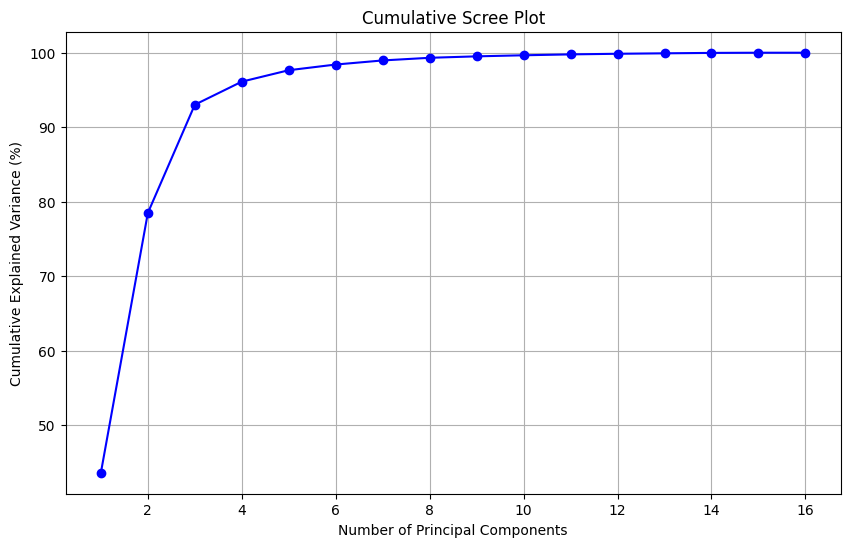

In [ ]:
"""
Principal component analysis for the 01% threshold group. Code also computes a cluster analysis afterwards if a user would like to investigate the
results of the respective PCA in that way. The cluster analysis results are however, NOT part of Carl et al. (in prep., 2026). The outcome of this code
utilized in the paper is the bar chart created in the code part "Distance in PC space (relative to reference)"
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import skew, entropy
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px
import plotly.subplots as sp

##############################
# Helper functions for features
##############################

def compute_pdf(series, num_bins=20):
    """Generic PDF without fixed range (for lengths & curvatures)."""
    hist, _ = np.histogram(series, bins=num_bins, density=True)
    if hist.sum() > 0:
        pdf = hist / hist.sum()
    else:
        pdf = np.zeros_like(hist)
    return pdf


def compute_pdf_fixed(series, num_bins=20, bin_range=(-1, 1)):
    """PDF with fixed range (for gradient data)."""
    hist, _ = np.histogram(series, bins=num_bins, range=bin_range, density=True)
    if hist.sum() > 0:
        pdf = hist / hist.sum()
    else:
        pdf = np.zeros_like(hist)
    return pdf



def normalize_feature(series, center_type="mean"):
    if center_type == "mean":
        centered = series - np.mean(series)
    elif center_type == "zero":  # for gradients
        centered = series  # leave zero where it is
    else:
        raise ValueError("Unknown center_type")

    max_val = np.max(np.abs(centered))
    if max_val == 0:
        return centered
    return centered / max_val


def compute_feature_vector(series, num_pdf=20, center_type="mean", fixed_range=False):
    arr = np.array(series, dtype=float)

    finite_vals = arr[np.isfinite(arr)]
    if finite_vals.size > 0:
        max_finite = np.max(finite_vals)
        min_finite = np.min(finite_vals)
        arr = np.where(np.isposinf(arr), max_finite, arr)
        arr = np.where(np.isneginf(arr), min_finite, arr)
    else:
        arr = np.nan_to_num(arr, nan=0.0)

    # Apply chosen centering
    norm_series = normalize_feature(arr, center_type=center_type)

    # Use the right PDF function
    if fixed_range:
        pdf = compute_pdf_fixed(norm_series, num_bins=num_pdf)
    else:
        pdf = compute_pdf(norm_series, num_bins=num_pdf)

    return pdf


##############################
# Loading main (CSV) data and computing features
##############################

def load_main_data(directory, direction):
    datasets = []
    files = sorted(os.listdir(directory))
    for filename in files:
        if filename.endswith('.csv'):
            filepath = os.path.join(directory, filename)
            df = pd.read_csv(filepath)
            if direction == '1st':
                required_columns = ['Horizontal Length', 'Vertical Length']
            elif direction == '2nd':
                required_columns = ['Horizontal Length', 'Vertical Length']  # Will rename below
            missing_columns = [col for col in required_columns if col not in df.columns]
            if missing_columns:
                print(f"Warning: In file '{filepath}', missing columns: {missing_columns}. Skipping.")
                continue
            if direction == '1st':
                df = df[required_columns]
            elif direction == '2nd':
                df = df.rename(columns={'Horizontal Length': 'Horizontal Length Orthogonal'})
                df = df[['Horizontal Length Orthogonal', 'Vertical Length']]
            datasets.append(df)
    if datasets:
        return pd.concat(datasets, ignore_index=True)
    else:
        return pd.DataFrame()

def get_main_features(dataset_dir):
    # Load data from both directions
    dir_1st = os.path.join(dataset_dir, '1st direction')
    dir_2nd = os.path.join(dataset_dir, '2nd direction')
    df1 = load_main_data(dir_1st, '1st')
    df2 = load_main_data(dir_2nd, '2nd')
    
    features = {}
    # Combine Horizontal Length and Horizontal Length Orthogonal into Horizontal Length Combined
    if not df1.empty and not df2.empty:
        combined = np.concatenate([df1['Horizontal Length'].dropna().values, 
                                   df2['Horizontal Length Orthogonal'].dropna().values])
    elif not df1.empty:
        combined = df1['Horizontal Length'].dropna().values
    elif not df2.empty:
        combined = df2['Horizontal Length Orthogonal'].dropna().values
    else:
        combined = np.array([])
    if combined.size > 0:
        features['Horizontal Length Combined'] = compute_feature_vector(combined)
    
    # Combine Vertical Length from both directions
    if not df1.empty and not df2.empty:
        z_combined = pd.concat([df1[['Vertical Length']], df2[['Vertical Length']]], axis=0, ignore_index=True)
        z_combined = pd.DataFrame(z_combined, columns=['Vertical Length'])
        z_values = z_combined['Vertical Length'].dropna().values
    elif not df1.empty:
        z_values = df1['Vertical Length'].dropna().values
    elif not df2.empty:
        z_values = df2['Vertical Length'].dropna().values
    else:
        z_values = np.array([])
    if z_values.size > 0:
        features['Vertical Length'] = compute_feature_vector(z_values)
    return features

##############################
# Loading gradient &  features from Excel files
##############################

def load_grad_data(dataset_name, grad_dir):
    file_path = os.path.join(grad_dir, f"{dataset_name}.xlsx")
    if os.path.isfile(file_path):
        df = pd.read_excel(file_path)
        # Second column: Gradients; third column: 
        gradients = df.iloc[:, 1].dropna().values
        return {'Gradients': gradients}
    else:
        return None

##############################
# Main workflow: Build combined feature matrix and perform clustering
##############################

def main():
    # Use only one base directory.
    base_directory = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Raw data 101"
    
    grad_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Grad & curv\Gradient & curvature Auswertung"
    
    feature_rows = []
    dataset_labels = []
    
   
    dataset_folders = [d for d in os.listdir(base_directory) 
                       if os.path.isdir(os.path.join(base_directory, d))]
    for dataset in dataset_folders:
        dataset_dir = os.path.join(base_directory, dataset)
        dataset_labels.append(dataset)
        
            # Get main features (only use 'Y Length Combined' and 'Z Length')
        main_feats = get_main_features(dataset_dir)
            
            # Load gradient features from Excel file
        grad = load_grad_data(dataset, grad_dir)
        if grad is not None:
            grad_feat = compute_feature_vector(grad['Gradients'], center_type="zero", fixed_range=True)
        else:
            feat_length = 20  # Each PDF vector is of length 20
            grad_feat = np.full(feat_length, np.nan)

            
            # Build the feature vector: use only 'Y Length Combined', 'Z Length', 'Gradients'
        feat_list = []
        expected_keys = ['Horizontal Length Combined', 'Vertical Length']
        missing = []
        for key in expected_keys:
            if key in main_feats:
                feat_list.append(main_feats[key])
            else:
                missing.append(key)
                feat_list.append(np.full(20, np.nan))
            # Add gradient a features
        if np.isnan(grad_feat).any():
            missing.append("Gradients")
        feat_list.append(grad_feat)
        combined_feature_vector = np.concatenate(feat_list)
            
        if np.isnan(combined_feature_vector).any():
            print(f"Skipping dataset {dataset} due to missing features: {', '.join(missing)}")
        else:
            feature_rows.append(combined_feature_vector)
    
    if not feature_rows:
        print("No valid datasets found. Exiting.")
        return
    
    # Build the feature matrix (each row is an 60-element vector)
    feature_matrix = pd.DataFrame(feature_rows, index=dataset_labels)
    print("Feature matrix shape:", feature_matrix.shape)
    output_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\clustering Auswertung\101"
    # --- PCA and Clustering ---
    n_components = min(60, feature_matrix.shape[1], feature_matrix.shape[0])
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(feature_matrix)
    pca_df = pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(n_components)])
    pca_df['Dataset'] = dataset_labels

    # Plot cumulative scree plot (showing cumulative explained variance)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n_components + 1), cumulative_variance * 100, marker='o', color='blue')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance (%)')
    plt.title('Cumulative Scree Plot')
    plt.grid(True)
    plt.savefig(os.path.join(output_dir, 'cumulative_scree_plot.pdf'), format='pdf', dpi=300)
    plt.show()




    # Determine optimal k using elbow plot and silhouette score.
    max_k = min(60, pca_df.shape[0] -1)
    inertia = []
    silhouette_scores = []
    K_range = range(2, max_k + 1)
#cluster plot reproduzierbar (elbow plot nicht)  mit:     kmeans =KMeans(
           # n_clusters=k,
          #  init='k-means++',
            #n_init=10,
           # tol=1e-4,
          #  max_iter=300,
         #   algorithm='elkan',
        #    random_state=16
       # )
    for k in K_range:
        #kmeans = KMeans(n_clusters=k, random_state=19
        #               ) 
        kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        tol=1e-4,
        max_iter=300,
        algorithm='elkan',
        random_state=40)
        

        labels = kmeans.fit_predict(pca_df.select_dtypes(include=[np.number]))
        inertia.append(kmeans.inertia_)
        silhouette_avg = silhouette_score(pca_df.select_dtypes(include=[np.number]), labels)
        silhouette_scores.append(silhouette_avg)

    # Plot Elbow and Silhouette Score
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Inertia', color='tab:blue')
    ax1.plot(K_range, inertia, marker='o', linestyle='-', color='tab:blue', label='Inertia')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax1.twinx()
    ax2.set_ylabel('Silhouette Score', color='tab:orange')
    ax2.plot(K_range, silhouette_scores, marker='s', linestyle='--', color='tab:orange', label='Silhouette Score')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    plt.title('Elbow Plot & Silhouette Score for Optimal Clusters')
    fig.tight_layout()
    plt.savefig(os.path.join(output_dir, 'elbow_silhouette_plot.pdf'), format='pdf', dpi=300)
    plt.show()

    variances = feature_matrix.var(axis=0)
    plt.figure(figsize=(12,4))
    plt.plot(variances, marker='o')
    plt.axvline(19, color='orange', linestyle='--', label='end horizontal data combined')
    plt.axvline(39, color='black', linestyle='--', label='end vertical data')
    plt.axvline(59, color='blue', linestyle='--', label='end gradient data')
    plt.legend()
    plt.ylabel('Variance')
    plt.xlabel('Feature index (0–59)')
    plt.title('Per‑feature variance')
    plt.savefig(os.path.join(output_dir, 'Per‑feature variance.pdf'), format='pdf', dpi=300)
    plt.show()





    best_k = 5  # Manually set number of clusters
    kmeans = KMeans(n_clusters=5, random_state=40)#rs=42
    
    clusters = kmeans.fit_predict(pca_df.select_dtypes(include=[np.number]))
    pca_df['Cluster'] = clusters

        # --- after: pca_df['Cluster'] = clusters ---

    # ---------------------------
    # Distance in PC space (relative to reference)
    # ---------------------------
    dist_output_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Clustering Auswertung/101"
    os.makedirs(dist_output_dir, exist_ok=True)

    reference_name = "Juliusburg_Koestorf-Rosenthal_initial"
    pc_columns = [f"PC{i+1}" for i in range(n_components)]

    coords = pca_df[pc_columns].to_numpy()
    datasets = pca_df['Dataset'].tolist()

    try:
        ref_idx = datasets.index(reference_name)
    except ValueError:
        print(f"Reference dataset '{reference_name}' not found.")
        ref_idx = None

    if ref_idx is not None:
        ref_vec = coords[ref_idx]

        distances_list = []

        for i, (name, vec) in enumerate(zip(datasets, coords)):
            if name == reference_name:
                continue  # <-- exclude reference dataset entirely
            dist = np.linalg.norm(vec - ref_vec)
            distances_list.append((name, dist))

        # Build dataframe and sort ascending
        dist_df = pd.DataFrame(distances_list, columns=['Dataset', 'Distance'])
        # ---------------------------
        # Customize & plot distances (replacement block)
        # ---------------------------
        
        import re
        FONT_SIZE = 20

        # Update rcParams so axes labels, ticks, titles, legend, etc. use the bigger size
        plt.rcParams.update({
            'font.size': FONT_SIZE,
            'axes.titlesize': FONT_SIZE + 1,
            'axes.labelsize': FONT_SIZE + 1,
            'xtick.labelsize': FONT_SIZE - 2,
            'ytick.labelsize': FONT_SIZE - 2,
            'legend.fontsize': FONT_SIZE - 2,
            'figure.titlesize': FONT_SIZE + 1
        })
        # order you requested (canonical form used for ordering)
        order_labels = [
            "10 s 10 b",
            "10 s 0 b",
            "8 s 8 b",
            "5 s 5 b",
            "4 s 4 b",
            "0 s 10 b",
            "3 s 3 b",
            "3 s 2 b",
            "3 s 1 b",
            "2 s 3 b",
            "2 s 2 b",
            "2 s 1 b",
            "1 s 3 b",
            "1 s 2 b",
            "1 s 1 b",
        ]
        
        def extract_config_key(dataset_name):
            """
            Turn dataset names like:
              '4 sections 4 boreholes_hull_GE_150_smoothed'
            into canonical keys like:
              '4 s 4 b'
            Falls back to the first two numbers found if exact phrase not present.
            """
            s = str(dataset_name)
            m = re.search(r"(\d+)\s*sections\s*(\d+)\s*boreholes", s, flags=re.IGNORECASE)
            if m:
                return f"{int(m.group(1))} s {int(m.group(2))} b"
            # fallback: two numbers anywhere in the string
            nums = re.findall(r"(\d+)", s)
            if len(nums) >= 2:
                return f"{int(nums[0])} s {int(nums[1])} b"
                return s  # give up — return original
        
        def display_label_from_key(key):
            """
            Convert canonical key '4 s 4 b' -> compact display '4s 4b'
            """
            m = re.match(r"(\d+)\s*s\s*(\d+)\s*b", str(key))
            if m:
             #   return f"{m.group(1)}s {m.group(2)}b"
                return str(key)
        
        # Build a DataFrame of distances (unsorted)
        dist_df = pd.DataFrame(distances_list, columns=['Dataset', 'Distance'])
        
        # Add canonical config key and display label
        dist_df['ConfigKey'] = dist_df['Dataset'].apply(extract_config_key)
        dist_df['DisplayLabel'] = dist_df['ConfigKey'].apply(display_label_from_key)
        
        # Reorder rows according to order_labels (preserve datasets not in list at the end)
        ordered_rows = []
        seen = set()
        for key in order_labels:
            matches = dist_df[dist_df['ConfigKey'] == key]
            if not matches.empty:
                for _, r in matches.iterrows():
                    ordered_rows.append(r)
                    seen.add(r['Dataset'])
        
        # append any remaining datasets not matched by order_labels
        for _, r in dist_df.iterrows():
            if r['Dataset'] not in seen:
                ordered_rows.append(r)
        
        if not ordered_rows:
            raise RuntimeError("No distances to plot after ordering step.")
        
        final_df = pd.DataFrame(ordered_rows).reset_index(drop=True)
        
        # Plot: orange bars, black edge
        plt.figure(figsize=(12, 6))
        x = range(len(final_df))
       # plt.bar(x, final_df['Distance'], color='orange', edgecolor='black')
        bars = plt.bar(x, final_df['Distance'], color='orange', edgecolor='black')
      #  for bar in bars:
       #     height = bar.get_height()





        
        # X tick labels -> compact labels, rotate for readability
        plt.xticks(x, final_df['DisplayLabel'], rotation=90, ha='right')
        
        # Add numeric values above each bar
        ymin, ymax = plt.ylim()
        # offset as a fraction of the data range
        offset = (final_df['Distance'].max() - final_df['Distance'].min()) * 0.02 if final_df['Distance'].max() != final_df['Distance'].min() else 0.01
        for bar, val in zip(bars, final_df['Distance']):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                val,
                f"{val:.3f}",
                ha='center',
                va='bottom',
                rotation=45,
                fontsize=15,
                color='black'
            )
        ytop=ymax +0.3
        print(f" ytop: {ytop}")
        plt.ylim(0, ytop)

        import json

        with open("plot_config.json", "w") as f:
            json.dump({"ytop": ytop}, f)
        # Horizontal green mean line
        mean_val = final_df['Distance'].mean()
        plt.axhline(mean_val, color='green', linestyle='--', linewidth=1.5, label=f"Mean = {mean_val:.3f}")
        # Put the mean text near top-right inside axes
        plt.text(0.99, 0.99, f"Mean: {mean_val:.3f}", transform=plt.gca().transAxes,
                 ha="right", va="top", fontsize=18, color='green')
        
        plt.ylabel('Euclidean distance in PC space')
        plt.xlabel('Dataset configuration')
        plt.title(f"Distances in PC space - Threshold 1%")
        plt.tight_layout()
        
        # Save
        pdf_path = os.path.join(dist_output_dir, "distances_in_PC_space_Juliusburg_Koestorf-Rosenthal_custom_order.pdf")
        plt.savefig(pdf_path, format='pdf')
        plt.close()
        print(f"Saved distance plot to: {pdf_path}")
        
        # Also re-save the ordered distances as Excel for reproducibility
        excel_path = os.path.join(dist_output_dir, "distances_in_PC_space_Juliusburg_Koestorf-Rosenthal_custom_order.xlsx")
        final_df[['Dataset','ConfigKey','DisplayLabel','Distance']].to_excel(excel_path, index=False)
        print(f"Saved ordered distances table to: {excel_path}")








    
    output_excel = os.path.join(r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\clustering Auswertung", 'cluster_assignments_P3.xlsx')
    #save_cluster_assignments(pca_df, output_excel)
    
    #dark_colors = ['#1f77b4', '#ff7f0e','#ffb691', '#2ca02c', '#d62728', '#9467bd', 
     #          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    #dark_colors = ['#1f77b4',   '#d62728',  '#7f7f7f', '#ff7f0e', '#9467bd',
               #'#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',  '#2ca02c'] #'#fff3234',
    #dark_colors = [   'rgb(0,0,0)','rgb(230,159,0)','rgb(86, 180, 233)','rgb(0, 114, 178)','rgb(0, 158, 115)','rgb(213, 94, 0)','rgb(204, 121, 167)','rgb(240, 228, 66)' ]
    
    
    raw_colors = [
    (0, 0, 0),
    (230, 159, 0),
    (86, 180, 233),
    (204, 121, 167),
    (0, 158, 115),
    (213, 94, 0),
    (0, 114, 178),
    (240, 228, 66)
]

   # dark_colors = [(r/255, g/255, b/255) for r, g, b in raw_colors]
    
    
  #  selected_colors = dark_colors[:5]
    selected_colors = [mcolors.to_hex((r/255, g/255, b/255)) for r, g, b in raw_colors] 

    # ---------------------------
    # Interactive PC Diagram Selection
    # ---------------------------
    # Ask the user to input three PC pairs to plot
    print("\nEnter pairs of principal components to plot, in the format 'x,y' separated by semicolons.")
    print("For example: 1,20; 5,15; 3,7")
    input_str = input("Enter 3 PC pairs: ")
    # Split by semicolon, then parse each pair
    pairs = [pair.strip() for pair in input_str.split(';') if pair.strip()]
    scatter_plots = []
    for pair in pairs:
        try:
            pc1, pc2 = [int(x.strip()) for x in pair.split(',')]
            # Validate the PC indices (they should be between 1 and n_components)
            if pc1 < 1 or pc2 < 1 or pc1 > n_components or pc2 > n_components:
                print(f"Invalid PC indices in pair '{pair}'. Valid indices are between 1 and {n_components}. Skipping this pair.")
                continue
            highlighted_datasets = {
                "Juliusburg_Koestorf-Rosenthal_initial"
            }
            
            # Define marker styles
            marker_symbols = []
            marker_sizes = []
            
            for name in pca_df['Dataset']:
                if name in highlighted_datasets:
                    marker_symbols.append('star')
                    marker_sizes.append(14)  # larger size for stars
                else:
                    marker_symbols.append('circle')
                    marker_sizes.append(8)   # default circle size
            
            # Add marker info to DataFrame
            pca_df['Symbol'] = marker_symbols
            pca_df['Size'] = marker_sizes
            
            # Use Plotly Express scatter with custom symbols and sizes
            fig = px.scatter(
                pca_df, 
                x=f'PC{pc1}', 
                y=f'PC{pc2}', 
                color=pca_df['Cluster'].astype(str),
                hover_name='Dataset', 
                symbol='Symbol',
                size='Size',
                color_discrete_sequence=selected_colors,
                title=f'pc{pc1} vs. pc{pc2}',
            )
            
            # Fix marker size scaling (size is exact, not scaled by data range)
            fig.update_traces(marker=dict(sizemode='diameter', sizeref=1, sizemin=1))
            
            scatter_plots.append(fig)
        except Exception as e:
            print(f"Error processing pair '{pair}': {e}")
    
    # Display each scatter plot
    for fig in scatter_plots:
        fig.show()
    
        # ---------------------------
    # Contribution graph for PCs 1 to 12
    # ---------------------------
    contrib_components = min(12, n_components)
    contributions = pd.DataFrame(
        pca.components_.T[:, :contrib_components],
        index=feature_matrix.columns,
        columns=[f'PC{i+1}' for i in range(contrib_components)]
    )

    print("Feature contributions to principal components (PC1 to PC12):")
    #print(contributions)

    # plotly heatmap
    fig = px.imshow(
        contributions,
        text_auto=True,
        aspect="auto",
        title="Contributions of Original Features to PCs (PC1 to PC12)",
        color_continuous_scale='Viridis'
    )

    # add more ticks on the colorbar
    fig.update_coloraxes(colorbar=dict(
        title="Loading",
        tickmode='linear',
        tick0=0.0,
        dtick=0.10,     # a tick every 0.05 units
        tickfont=dict(size=8),
        lenmode='fraction',
        len=0.8
    ))

    fig.show()
    #fig.write_image(os.path.join(output_dir, 'pc_contributions_heatmap.pdf'), format='pdf', scale=3)


if __name__ == "__main__":
    main()

Feature matrix shape: (16, 60)


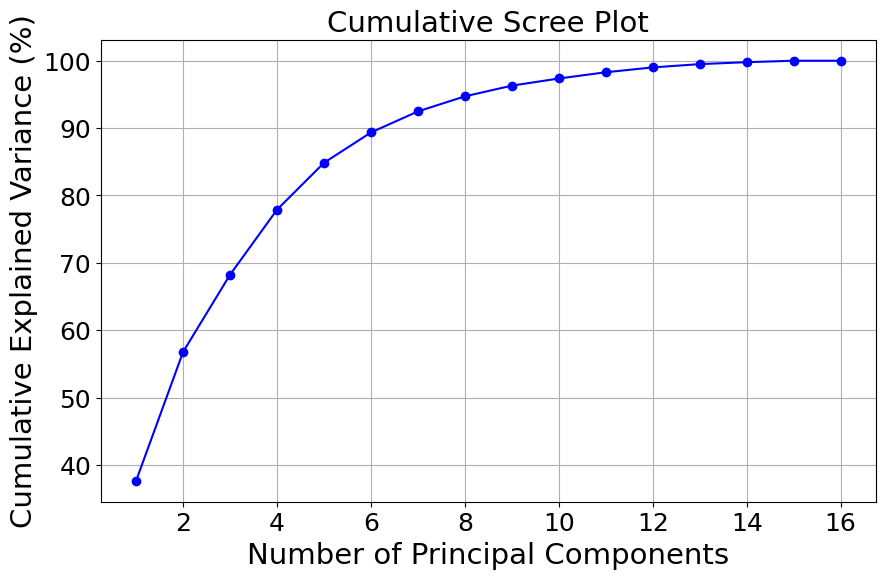

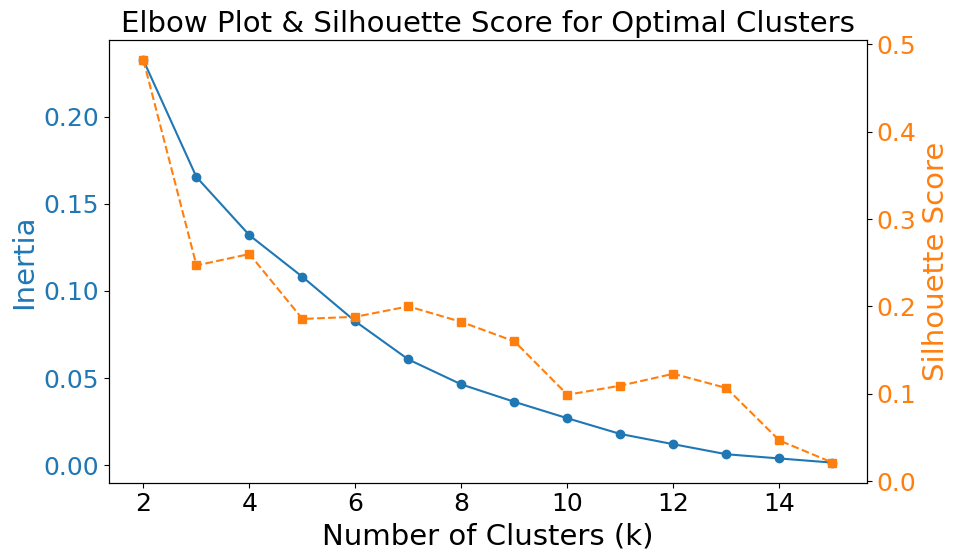

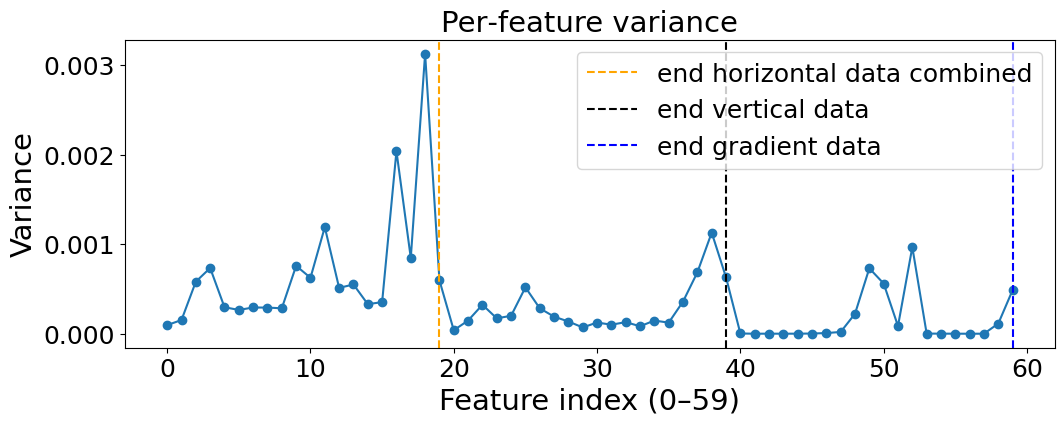

Saved distance plot to: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Clustering Auswertung/125\distances_in_PC_space_Gielow_custom_order.pdf
Saved ordered distances table to: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Clustering Auswertung/125\distances_in_PC_space_Gielow_custom_order.xlsx

Enter pairs of principal components to plot, in the format 'x,y' separated by semicolons.
For example: 1,20; 5,15; 3,7


Enter 3 PC pairs:  1,2


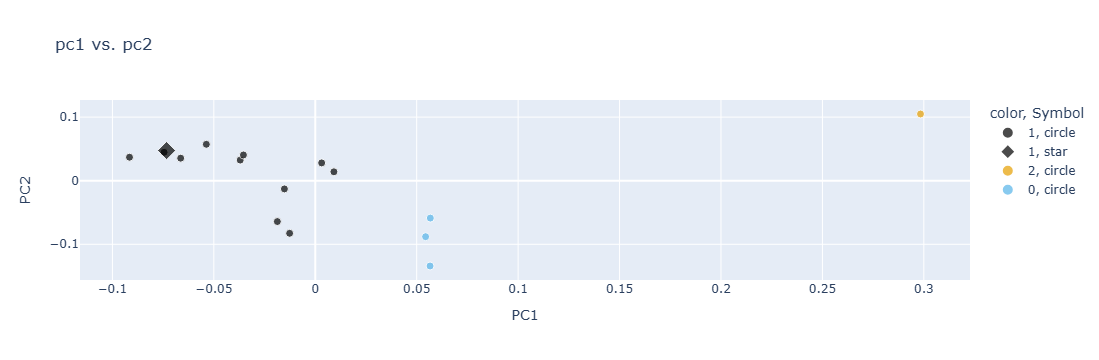

Feature contributions to principal components (PC1 to PC12):


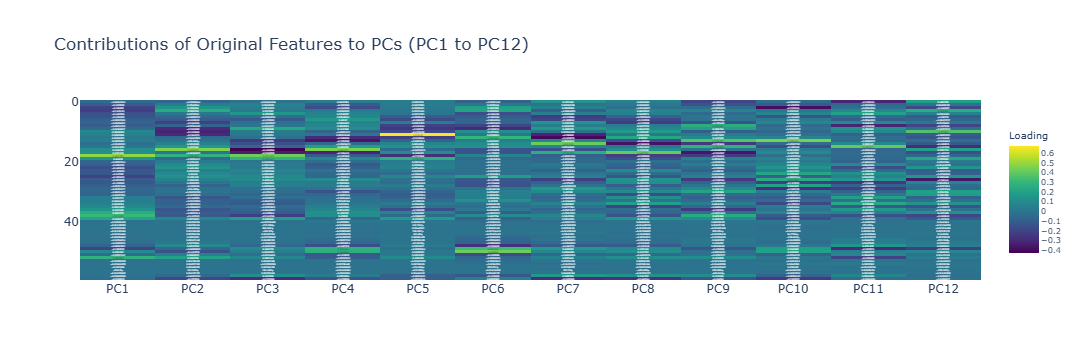

In [11]:
"""
Principal component analysis for the 25% threshold group. Code also computes a cluster analysis afterwards if a user would like to investigate the
results of the respective PCA in that way. The cluster analysis results are however, NOT part of Carl et al. (in prep., 2026). The outcome of this code
utilized in the paper is the bar chart created in the code part "Distance in PC space (relative to reference)"
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import skew, entropy
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px
import plotly.subplots as sp

##############################
# Helper functions for features
##############################

def compute_pdf(series, num_bins=20):
    """Generic PDF without fixed range (for lengths & curvatures)."""
    hist, _ = np.histogram(series, bins=num_bins, density=True)
    if hist.sum() > 0:
        pdf = hist / hist.sum()
    else:
        pdf = np.zeros_like(hist)
    return pdf


def compute_pdf_fixed(series, num_bins=20, bin_range=(-1, 1)):
    """PDF with fixed range (for gradient data)."""
    hist, _ = np.histogram(series, bins=num_bins, range=bin_range, density=True)
    if hist.sum() > 0:
        pdf = hist / hist.sum()
    else:
        pdf = np.zeros_like(hist)
    return pdf



def normalize_feature(series, center_type="mean"):
    if center_type == "mean":
        centered = series - np.mean(series)
    elif center_type == "zero":  # for gradients
        centered = series  # leave zero where it is
    else:
        raise ValueError("Unknown center_type")

    max_val = np.max(np.abs(centered))
    if max_val == 0:
        return centered
    return centered / max_val


def compute_feature_vector(series, num_pdf=20, center_type="mean", fixed_range=False):
    arr = np.array(series, dtype=float)

    finite_vals = arr[np.isfinite(arr)]
    if finite_vals.size > 0:
        max_finite = np.max(finite_vals)
        min_finite = np.min(finite_vals)
        arr = np.where(np.isposinf(arr), max_finite, arr)
        arr = np.where(np.isneginf(arr), min_finite, arr)
    else:
        arr = np.nan_to_num(arr, nan=0.0)

    # Apply chosen centering
    norm_series = normalize_feature(arr, center_type=center_type)

    # Use the right PDF function
    if fixed_range:
        pdf = compute_pdf_fixed(norm_series, num_bins=num_pdf)
    else:
        pdf = compute_pdf(norm_series, num_bins=num_pdf)

    return pdf


##############################
# Loading main (CSV) data and computing features
##############################

def load_main_data(directory, direction):
    datasets = []
    files = sorted(os.listdir(directory))
    for filename in files:
        if filename.endswith('.csv'):
            filepath = os.path.join(directory, filename)
            df = pd.read_csv(filepath)
            if direction == '1st':
                required_columns = ['Horizontal Length', 'Vertical Length']
            elif direction == '2nd':
                required_columns = ['Horizontal Length', 'Vertical Length']  # Will rename below
            missing_columns = [col for col in required_columns if col not in df.columns]
            if missing_columns:
                print(f"Warning: In file '{filepath}', missing columns: {missing_columns}. Skipping.")
                continue
            if direction == '1st':
                df = df[required_columns]
            elif direction == '2nd':
                df = df.rename(columns={'Horizontal Length': 'Horizontal Length Orthogonal'})
                df = df[['Horizontal Length Orthogonal', 'Vertical Length']]
            datasets.append(df)
    if datasets:
        return pd.concat(datasets, ignore_index=True)
    else:
        return pd.DataFrame()

def get_main_features(dataset_dir):
    # Load data from both directions
    dir_1st = os.path.join(dataset_dir, '1st direction')
    dir_2nd = os.path.join(dataset_dir, '2nd direction')
    df1 = load_main_data(dir_1st, '1st')
    df2 = load_main_data(dir_2nd, '2nd')
    
    features = {}
    # Combine Horizontal Length and Horizontal Length Orthogonal into Horizontal Length Combined
    if not df1.empty and not df2.empty:
        combined = np.concatenate([df1['Horizontal Length'].dropna().values, 
                                   df2['Horizontal Length Orthogonal'].dropna().values])
    elif not df1.empty:
        combined = df1['Horizontal Length'].dropna().values
    elif not df2.empty:
        combined = df2['Horizontal Length Orthogonal'].dropna().values
    else:
        combined = np.array([])
    if combined.size > 0:
        features['Horizontal Length Combined'] = compute_feature_vector(combined)
    
    # Combine Vertical Length from both directions
    if not df1.empty and not df2.empty:
        z_combined = pd.concat([df1[['Vertical Length']], df2[['Vertical Length']]], axis=0, ignore_index=True)
        z_combined = pd.DataFrame(z_combined, columns=['Vertical Length'])
        z_values = z_combined['Vertical Length'].dropna().values
    elif not df1.empty:
        z_values = df1['Vertical Length'].dropna().values
    elif not df2.empty:
        z_values = df2['Vertical Length'].dropna().values
    else:
        z_values = np.array([])
    if z_values.size > 0:
        features['Vertical Length'] = compute_feature_vector(z_values)
    return features

##############################
# Loading gradient &  features from Excel files
##############################

def load_grad_data(dataset_name, grad_dir):
    file_path = os.path.join(grad_dir, f"{dataset_name}.xlsx")
    if os.path.isfile(file_path):
        df = pd.read_excel(file_path)
        # Second column: Gradients; third column: 
        gradients = df.iloc[:, 1].dropna().values
        return {'Gradients': gradients}
    else:
        return None

##############################
# Main workflow: Build combined feature matrix and perform clustering
##############################

def main():
    # Use only one base directory.
    base_directory = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Raw data 125"
    
    grad_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Grad & curv\Gradient & curvature Auswertung"
    
    feature_rows = []
    dataset_labels = []
    
   
    dataset_folders = [d for d in os.listdir(base_directory) 
                       if os.path.isdir(os.path.join(base_directory, d))]
    for dataset in dataset_folders:
        dataset_dir = os.path.join(base_directory, dataset)
        dataset_labels.append(dataset)
        
            # Get main features (only use 'Y Length Combined' and 'Z Length')
        main_feats = get_main_features(dataset_dir)
            
            # Load gradient features from Excel file
        grad = load_grad_data(dataset, grad_dir)
        if grad is not None:
            grad_feat = compute_feature_vector(grad['Gradients'], center_type="zero", fixed_range=True)
        else:
            feat_length = 20  # Each PDF vector is of length 20
            grad_feat = np.full(feat_length, np.nan)

            
            # Build the feature vector: use only 'Y Length Combined', 'Z Length', 'Gradients'
        feat_list = []
        expected_keys = ['Horizontal Length Combined', 'Vertical Length']
        missing = []
        for key in expected_keys:
            if key in main_feats:
                feat_list.append(main_feats[key])
            else:
                missing.append(key)
                feat_list.append(np.full(20, np.nan))
            # Add gradient a features
        if np.isnan(grad_feat).any():
            missing.append("Gradients")
        feat_list.append(grad_feat)
        combined_feature_vector = np.concatenate(feat_list)
            
        if np.isnan(combined_feature_vector).any():
            print(f"Skipping dataset {dataset} due to missing features: {', '.join(missing)}")
        else:
            feature_rows.append(combined_feature_vector)
    
    if not feature_rows:
        print("No valid datasets found. Exiting.")
        return
    
    # Build the feature matrix (each row is an 60-element vector)
    feature_matrix = pd.DataFrame(feature_rows, index=dataset_labels)
    print("Feature matrix shape:", feature_matrix.shape)
    output_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\clustering Auswertung\125"
    # --- PCA and Clustering ---
    n_components = min(60, feature_matrix.shape[1], feature_matrix.shape[0])
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(feature_matrix)
    pca_df = pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(n_components)])
    pca_df['Dataset'] = dataset_labels

    # Plot cumulative scree plot (showing cumulative explained variance)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n_components + 1), cumulative_variance * 100, marker='o', color='blue')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance (%)')
    plt.title('Cumulative Scree Plot')
    plt.grid(True)
    plt.savefig(os.path.join(output_dir, 'cumulative_scree_plot.pdf'), format='pdf', dpi=300)
    plt.show()




    # Determine optimal k using elbow plot and silhouette score.
    max_k = min(60, pca_df.shape[0] -1)
    inertia = []
    silhouette_scores = []
    K_range = range(2, max_k + 1)
#cluster plot reproduzierbar (elbow plot nicht)  mit:     kmeans =KMeans(
           # n_clusters=k,
          #  init='k-means++',
            #n_init=10,
           # tol=1e-4,
          #  max_iter=300,
         #   algorithm='elkan',
        #    random_state=16
       # )
    for k in K_range:
        #kmeans = KMeans(n_clusters=k, random_state=19
        #               ) 
        kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        tol=1e-4,
        max_iter=300,
        algorithm='elkan',
        random_state=40)
        

        labels = kmeans.fit_predict(pca_df.select_dtypes(include=[np.number]))
        inertia.append(kmeans.inertia_)
        silhouette_avg = silhouette_score(pca_df.select_dtypes(include=[np.number]), labels)
        silhouette_scores.append(silhouette_avg)

    # Plot Elbow and Silhouette Score
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Inertia', color='tab:blue')
    ax1.plot(K_range, inertia, marker='o', linestyle='-', color='tab:blue', label='Inertia')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax1.twinx()
    ax2.set_ylabel('Silhouette Score', color='tab:orange')
    ax2.plot(K_range, silhouette_scores, marker='s', linestyle='--', color='tab:orange', label='Silhouette Score')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    plt.title('Elbow Plot & Silhouette Score for Optimal Clusters')
    fig.tight_layout()
    plt.savefig(os.path.join(output_dir, 'elbow_silhouette_plot.pdf'), format='pdf', dpi=300)
    plt.show()

    variances = feature_matrix.var(axis=0)
    plt.figure(figsize=(12,4))
    plt.plot(variances, marker='o')
    plt.axvline(19, color='orange', linestyle='--', label='end horizontal data combined')
    plt.axvline(39, color='black', linestyle='--', label='end vertical data')
    plt.axvline(59, color='blue', linestyle='--', label='end gradient data')
    plt.legend()
    plt.ylabel('Variance')
    plt.xlabel('Feature index (0–59)')
    plt.title('Per‑feature variance')
    plt.savefig(os.path.join(output_dir, 'Per‑feature variance.pdf'), format='pdf', dpi=300)
    plt.show()





    best_k = 3  # Manually set number of clusters
    kmeans = KMeans(n_clusters=3, random_state=40)#rs=42
    
    clusters = kmeans.fit_predict(pca_df.select_dtypes(include=[np.number]))
    pca_df['Cluster'] = clusters

    # ---------------------------
    # Distance in PC space (relative to reference)
    # ---------------------------
    dist_output_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Clustering Auswertung/125"
    os.makedirs(dist_output_dir, exist_ok=True)

    reference_name = "Juliusburg_Koestorf-Rosenthal_initial"
    pc_columns = [f"PC{i+1}" for i in range(n_components)]

    coords = pca_df[pc_columns].to_numpy()
    datasets = pca_df['Dataset'].tolist()

    try:
        ref_idx = datasets.index(reference_name)
    except ValueError:
        print(f"Reference dataset '{reference_name}' not found.")
        ref_idx = None

    if ref_idx is not None:
        ref_vec = coords[ref_idx]

        distances_list = []

        for i, (name, vec) in enumerate(zip(datasets, coords)):
            if name == reference_name:
                continue  # <-- exclude reference dataset entirely
            dist = np.linalg.norm(vec - ref_vec)
            distances_list.append((name, dist))

        # Build dataframe and sort ascending
        dist_df = pd.DataFrame(distances_list, columns=['Dataset', 'Distance'])
        # ---------------------------
        # Customize & plot distances (replacement block)
        # ---------------------------
        
        import re
        FONT_SIZE = 20

        # Update rcParams so axes labels, ticks, titles, legend, etc. use the bigger size
        plt.rcParams.update({
            'font.size': FONT_SIZE,
            'axes.titlesize': FONT_SIZE + 1,
            'axes.labelsize': FONT_SIZE + 1,
            'xtick.labelsize': FONT_SIZE - 2,
            'ytick.labelsize': FONT_SIZE - 2,
            'legend.fontsize': FONT_SIZE - 2,
            'figure.titlesize': FONT_SIZE + 1
        })
        # order you requested (canonical form used for ordering)
        order_labels = [
            "10 s 10 b",
            "10 s 0 b",
            "8 s 8 b",
            "5 s 5 b",
            "4 s 4 b",
            "0 s 10 b",
            "3 s 3 b",
            "3 s 2 b",
            "3 s 1 b",
            "2 s 3 b",
            "2 s 2 b",
            "2 s 1 b",
            "1 s 3 b",
            "1 s 2 b",
            "1 s 1 b",
        ]
        
        def extract_config_key(dataset_name):
            """
            Turn dataset names like:
              '4 sections 4 boreholes_hull_GE_150_smoothed'
            into canonical keys like:
              '4 s 4 b'
            Falls back to the first two numbers found if exact phrase not present.
            """
            s = str(dataset_name)
            m = re.search(r"(\d+)\s*sections\s*(\d+)\s*boreholes", s, flags=re.IGNORECASE)
            if m:
                return f"{int(m.group(1))} s {int(m.group(2))} b"
            # fallback: two numbers anywhere in the string
            nums = re.findall(r"(\d+)", s)
            if len(nums) >= 2:
                return f"{int(nums[0])} s {int(nums[1])} b"
                return s  # give up — return original
        
        def display_label_from_key(key):
            """
            Convert canonical key '4 s 4 b' -> compact display '4s 4b'
            """
            m = re.match(r"(\d+)\s*s\s*(\d+)\s*b", str(key))
            if m:
             #   return f"{m.group(1)}s {m.group(2)}b"
                return str(key)
        
        # Build a DataFrame of distances (unsorted)
        dist_df = pd.DataFrame(distances_list, columns=['Dataset', 'Distance'])
        
        # Add canonical config key and display label
        dist_df['ConfigKey'] = dist_df['Dataset'].apply(extract_config_key)
        dist_df['DisplayLabel'] = dist_df['ConfigKey'].apply(display_label_from_key)
        
        # Reorder rows according to order_labels (preserve datasets not in list at the end)
        ordered_rows = []
        seen = set()
        for key in order_labels:
            matches = dist_df[dist_df['ConfigKey'] == key]
            if not matches.empty:
                for _, r in matches.iterrows():
                    ordered_rows.append(r)
                    seen.add(r['Dataset'])
        
        # append any remaining datasets not matched by order_labels
        for _, r in dist_df.iterrows():
            if r['Dataset'] not in seen:
                ordered_rows.append(r)
        
        if not ordered_rows:
            raise RuntimeError("No distances to plot after ordering step.")
        
        final_df = pd.DataFrame(ordered_rows).reset_index(drop=True)
        import json

        with open("plot_config.json") as f:
            ytop = json.load(f)["ytop"]
        # Plot: orange bars, black edge
        plt.figure(figsize=(12, 6))
        x = range(len(final_df))
      #  plt.bar(x, final_df['Distance'], color='orange', edgecolor='black')
        bars = plt.bar(x, final_df['Distance'], color='orange', edgecolor='black')
        # X tick labels -> compact labels, rotate for readability
        plt.xticks(x, final_df['DisplayLabel'], rotation=90, ha='right')
        
        ymin, ymax = plt.ylim()
        # offset as a fraction of the data range
        offset = (final_df['Distance'].max() - final_df['Distance'].min()) * 0.02 if final_df['Distance'].max() != final_df['Distance'].min() else 0.01
        for bar, val in zip(bars, final_df['Distance']):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                val,
                f"{val:.3f}",
                ha='center',
                va='bottom',
                rotation=45,
                fontsize=15,
                color='black'
            )

        plt.ylim(0, ytop)
        # Horizontal green mean line
        mean_val = final_df['Distance'].mean()
        plt.axhline(mean_val, color='green', linestyle='--', linewidth=1.5, label=f"Mean = {mean_val:.3f}")
        # Put the mean text near top-right inside axes
        plt.text(0.99, 0.99, f"Mean: {mean_val:.3f}", transform=plt.gca().transAxes,
                 ha="right", va="top", fontsize=18, color='green')
        
        plt.ylabel('Euclidean distance in PC space')
        plt.xlabel('Dataset configuration')
        plt.title(f"Distances in PC space - Threshold 25%")
        plt.tight_layout()
        
        # Save
        pdf_path = os.path.join(dist_output_dir, "distances_in_PC_space_Juliusburg_Koestorf-Rosenthal_custom_order.pdf")
        plt.savefig(pdf_path, format='pdf')
        plt.close()
        print(f"Saved distance plot to: {pdf_path}")
        
        # Also re-save the ordered distances as Excel for reproducibility
        excel_path = os.path.join(dist_output_dir, "distances_in_PC_space_Juliusburg_Koestorf-Rosenthal_custom_order.xlsx")
        final_df[['Dataset','ConfigKey','DisplayLabel','Distance']].to_excel(excel_path, index=False)
        print(f"Saved ordered distances table to: {excel_path}")



    

    output_excel = os.path.join(r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\clustering Auswertung", 'cluster_assignments_P3.xlsx')
    #save_cluster_assignments(pca_df, output_excel)
    
    #dark_colors = ['#1f77b4', '#ff7f0e','#ffb691', '#2ca02c', '#d62728', '#9467bd', 
     #          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    #dark_colors = ['#1f77b4',   '#d62728',  '#7f7f7f', '#ff7f0e', '#9467bd',
               #'#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',  '#2ca02c'] #'#fff3234',
    #dark_colors = [   'rgb(0,0,0)','rgb(230,159,0)','rgb(86, 180, 233)','rgb(0, 114, 178)','rgb(0, 158, 115)','rgb(213, 94, 0)','rgb(204, 121, 167)','rgb(240, 228, 66)' ]
    
    
    raw_colors = [
    (0, 0, 0),
    (230, 159, 0),
    (86, 180, 233),
    (204, 121, 167),
    (0, 158, 115),
    (213, 94, 0),
    (0, 114, 178),
    (240, 228, 66)
]

   # dark_colors = [(r/255, g/255, b/255) for r, g, b in raw_colors]
    
    
  #  selected_colors = dark_colors[:5]
    selected_colors = [mcolors.to_hex((r/255, g/255, b/255)) for r, g, b in raw_colors] 

    # ---------------------------
    # Interactive PC Diagram Selection
    # ---------------------------
    # Ask the user to input three PC pairs to plot
    print("\nEnter pairs of principal components to plot, in the format 'x,y' separated by semicolons.")
    print("For example: 1,20; 5,15; 3,7")
    input_str = input("Enter 3 PC pairs: ")
    # Split by semicolon, then parse each pair
    pairs = [pair.strip() for pair in input_str.split(';') if pair.strip()]
    scatter_plots = []
    for pair in pairs:
        try:
            pc1, pc2 = [int(x.strip()) for x in pair.split(',')]
            # Validate the PC indices (they should be between 1 and n_components)
            if pc1 < 1 or pc2 < 1 or pc1 > n_components or pc2 > n_components:
                print(f"Invalid PC indices in pair '{pair}'. Valid indices are between 1 and {n_components}. Skipping this pair.")
                continue
            highlighted_datasets = {
                "Juliusburg_Koestorf-Rosenthal_initial"
            }
            
            # Define marker styles
            marker_symbols = []
            marker_sizes = []
            
            for name in pca_df['Dataset']:
                if name in highlighted_datasets:
                    marker_symbols.append('star')
                    marker_sizes.append(14)  # larger size for stars
                else:
                    marker_symbols.append('circle')
                    marker_sizes.append(8)   # default circle size
            
            # Add marker info to DataFrame
            pca_df['Symbol'] = marker_symbols
            pca_df['Size'] = marker_sizes
            
            # Use Plotly Express scatter with custom symbols and sizes
            fig = px.scatter(
                pca_df, 
                x=f'PC{pc1}', 
                y=f'PC{pc2}', 
                color=pca_df['Cluster'].astype(str),
                hover_name='Dataset', 
                symbol='Symbol',
                size='Size',
                color_discrete_sequence=selected_colors,
                title=f'pc{pc1} vs. pc{pc2}',
            )
            
            # Fix marker size scaling (size is exact, not scaled by data range)
            fig.update_traces(marker=dict(sizemode='diameter', sizeref=1, sizemin=1))
            
            scatter_plots.append(fig)
        except Exception as e:
            print(f"Error processing pair '{pair}': {e}")
    
    # Display each scatter plot
    for fig in scatter_plots:
        fig.show()
    
        # ---------------------------
    # Contribution graph for PCs 1 to 12
    # ---------------------------
    contrib_components = min(12, n_components)
    contributions = pd.DataFrame(
        pca.components_.T[:, :contrib_components],
        index=feature_matrix.columns,
        columns=[f'PC{i+1}' for i in range(contrib_components)]
    )

    print("Feature contributions to principal components (PC1 to PC12):")
    #print(contributions)

    # plotly heatmap
    fig = px.imshow(
        contributions,
        text_auto=True,
        aspect="auto",
        title="Contributions of Original Features to PCs (PC1 to PC12)",
        color_continuous_scale='Viridis'
    )

    # add more ticks on the colorbar
    fig.update_coloraxes(colorbar=dict(
        title="Loading",
        tickmode='linear',
        tick0=0.0,
        dtick=0.10,     # a tick every 0.05 units
        tickfont=dict(size=8),
        lenmode='fraction',
        len=0.8
    ))

    fig.show()
    #fig.write_image(os.path.join(output_dir, 'pc_contributions_heatmap.pdf'), format='pdf', scale=3)


if __name__ == "__main__":
    main()

Feature matrix shape: (16, 60)


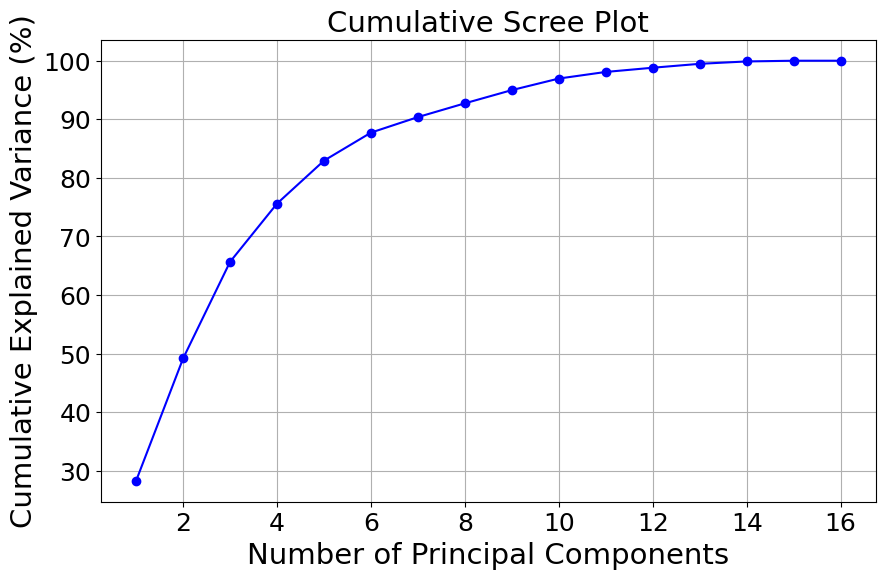

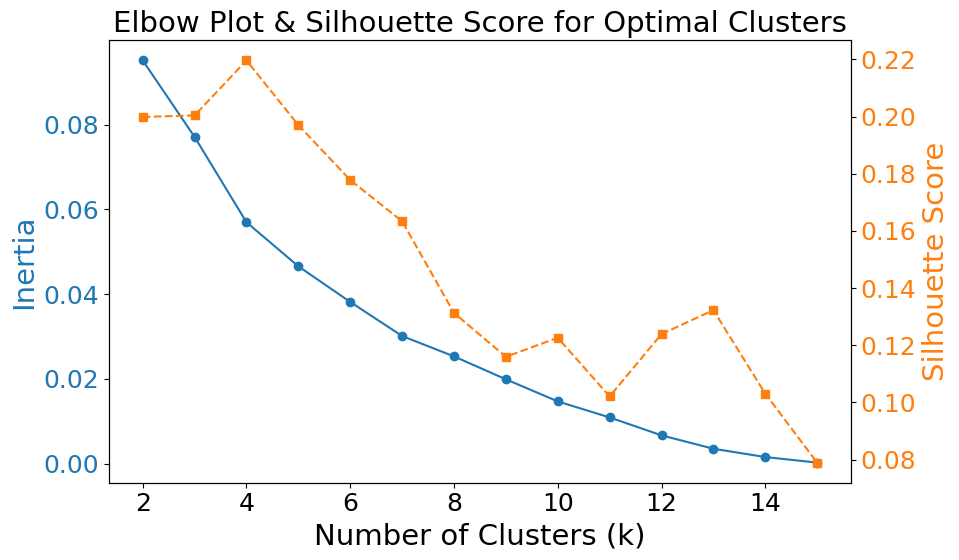

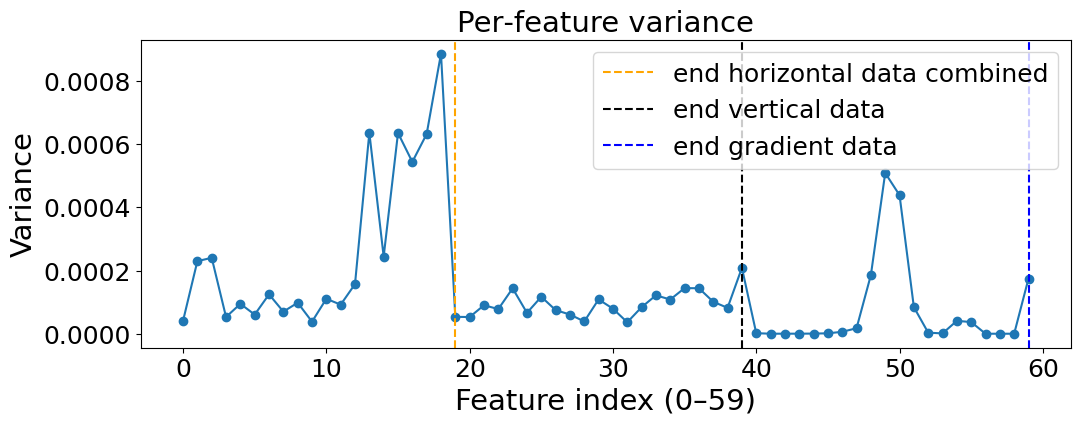

Saved distance plot to: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Clustering Auswertung/150\distances_in_PC_space_Gielow_custom_order.pdf
Saved ordered distances table to: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Clustering Auswertung/150\distances_in_PC_space_Gielow_custom_order.xlsx

Enter pairs of principal components to plot, in the format 'x,y' separated by semicolons.
For example: 1,20; 5,15; 3,7


Enter 3 PC pairs:  1,2


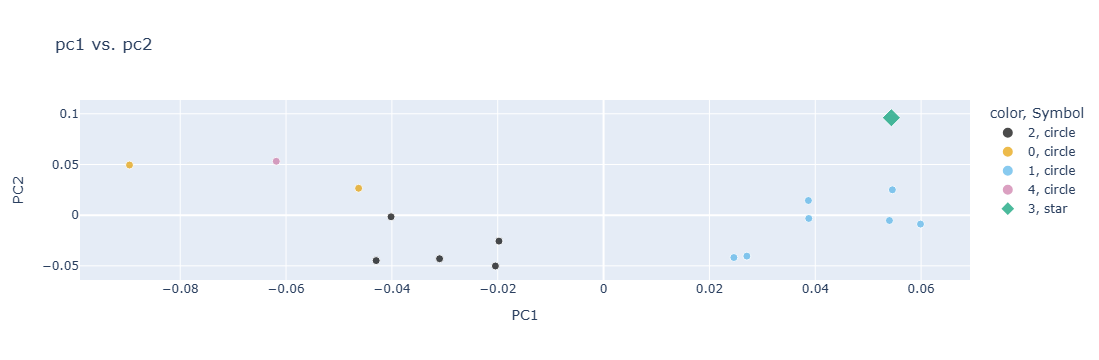

Feature contributions to principal components (PC1 to PC12):


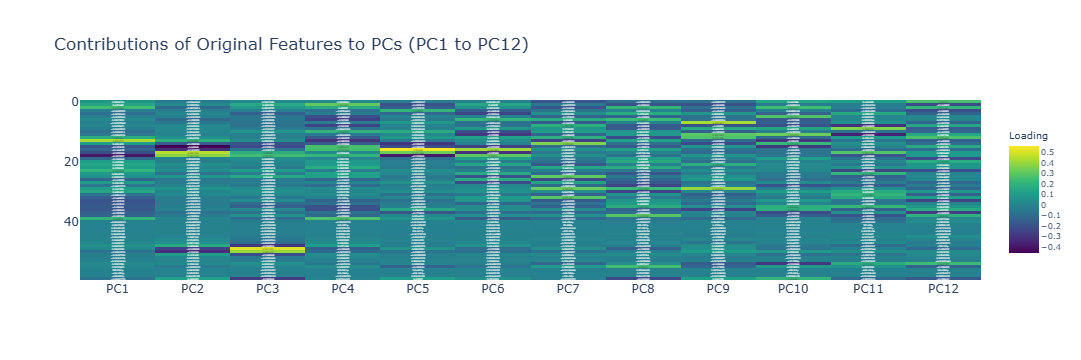

In [12]:
"""
Principal component analysis for the 50% threshold group. Code also computes a cluster analysis afterwards if a user would like to investigate the
results of the respective PCA in that way. The cluster analysis results are however, NOT part of Carl et al. (in prep., 2026). The outcome of this code
utilized in the paper is the bar chart created in the code part "Distance in PC space (relative to reference)"
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import skew, entropy
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px
import plotly.subplots as sp

##############################
# Helper functions for features
##############################

def compute_pdf(series, num_bins=20):
    """Generic PDF without fixed range (for lengths & curvatures)."""
    hist, _ = np.histogram(series, bins=num_bins, density=True)
    if hist.sum() > 0:
        pdf = hist / hist.sum()
    else:
        pdf = np.zeros_like(hist)
    return pdf


def compute_pdf_fixed(series, num_bins=20, bin_range=(-1, 1)):
    """PDF with fixed range (for gradient data)."""
    hist, _ = np.histogram(series, bins=num_bins, range=bin_range, density=True)
    if hist.sum() > 0:
        pdf = hist / hist.sum()
    else:
        pdf = np.zeros_like(hist)
    return pdf



def normalize_feature(series, center_type="mean"):
    if center_type == "mean":
        centered = series - np.mean(series)
    elif center_type == "zero":  # for gradients
        centered = series  # leave zero where it is
    else:
        raise ValueError("Unknown center_type")

    max_val = np.max(np.abs(centered))
    if max_val == 0:
        return centered
    return centered / max_val


def compute_feature_vector(series, num_pdf=20, center_type="mean", fixed_range=False):
    arr = np.array(series, dtype=float)

    finite_vals = arr[np.isfinite(arr)]
    if finite_vals.size > 0:
        max_finite = np.max(finite_vals)
        min_finite = np.min(finite_vals)
        arr = np.where(np.isposinf(arr), max_finite, arr)
        arr = np.where(np.isneginf(arr), min_finite, arr)
    else:
        arr = np.nan_to_num(arr, nan=0.0)

    # Apply chosen centering
    norm_series = normalize_feature(arr, center_type=center_type)

    # Use the right PDF function
    if fixed_range:
        pdf = compute_pdf_fixed(norm_series, num_bins=num_pdf)
    else:
        pdf = compute_pdf(norm_series, num_bins=num_pdf)

    return pdf


##############################
# Loading main (CSV) data and computing features
##############################

def load_main_data(directory, direction):
    datasets = []
    files = sorted(os.listdir(directory))
    for filename in files:
        if filename.endswith('.csv'):
            filepath = os.path.join(directory, filename)
            df = pd.read_csv(filepath)
            if direction == '1st':
                required_columns = ['Horizontal Length', 'Vertical Length']
            elif direction == '2nd':
                required_columns = ['Horizontal Length', 'Vertical Length']  # Will rename below
            missing_columns = [col for col in required_columns if col not in df.columns]
            if missing_columns:
                print(f"Warning: In file '{filepath}', missing columns: {missing_columns}. Skipping.")
                continue
            if direction == '1st':
                df = df[required_columns]
            elif direction == '2nd':
                df = df.rename(columns={'Horizontal Length': 'Horizontal Length Orthogonal'})
                df = df[['Horizontal Length Orthogonal', 'Vertical Length']]
            datasets.append(df)
    if datasets:
        return pd.concat(datasets, ignore_index=True)
    else:
        return pd.DataFrame()

def get_main_features(dataset_dir):
    # Load data from both directions
    dir_1st = os.path.join(dataset_dir, '1st direction')
    dir_2nd = os.path.join(dataset_dir, '2nd direction')
    df1 = load_main_data(dir_1st, '1st')
    df2 = load_main_data(dir_2nd, '2nd')
    
    features = {}
    # Combine Horizontal Length and Horizontal Length Orthogonal into Horizontal Length Combined
    if not df1.empty and not df2.empty:
        combined = np.concatenate([df1['Horizontal Length'].dropna().values, 
                                   df2['Horizontal Length Orthogonal'].dropna().values])
    elif not df1.empty:
        combined = df1['Horizontal Length'].dropna().values
    elif not df2.empty:
        combined = df2['Horizontal Length Orthogonal'].dropna().values
    else:
        combined = np.array([])
    if combined.size > 0:
        features['Horizontal Length Combined'] = compute_feature_vector(combined)
    
    # Combine Vertical Length from both directions
    if not df1.empty and not df2.empty:
        z_combined = pd.concat([df1[['Vertical Length']], df2[['Vertical Length']]], axis=0, ignore_index=True)
        z_combined = pd.DataFrame(z_combined, columns=['Vertical Length'])
        z_values = z_combined['Vertical Length'].dropna().values
    elif not df1.empty:
        z_values = df1['Vertical Length'].dropna().values
    elif not df2.empty:
        z_values = df2['Vertical Length'].dropna().values
    else:
        z_values = np.array([])
    if z_values.size > 0:
        features['Vertical Length'] = compute_feature_vector(z_values)
    return features

##############################
# Loading gradient &  features from Excel files
##############################

def load_grad_data(dataset_name, grad_dir):
    file_path = os.path.join(grad_dir, f"{dataset_name}.xlsx")
    if os.path.isfile(file_path):
        df = pd.read_excel(file_path)
        # Second column: Gradients; third column: 
        gradients = df.iloc[:, 1].dropna().values
        return {'Gradients': gradients}
    else:
        return None

##############################
# Main workflow: Build combined feature matrix and perform clustering
##############################

def main():
    # Use only one base directory.
    base_directory = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Raw data 150"
    
    grad_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Grad & curv\Gradient & curvature Auswertung"
    
    feature_rows = []
    dataset_labels = []
    
   
    dataset_folders = [d for d in os.listdir(base_directory) 
                       if os.path.isdir(os.path.join(base_directory, d))]
    for dataset in dataset_folders:
        dataset_dir = os.path.join(base_directory, dataset)
        dataset_labels.append(dataset)
        
            # Get main features (only use 'Y Length Combined' and 'Z Length')
        main_feats = get_main_features(dataset_dir)
            
            # Load gradient features from Excel file
        grad = load_grad_data(dataset, grad_dir)
        if grad is not None:
            grad_feat = compute_feature_vector(grad['Gradients'], center_type="zero", fixed_range=True)
        else:
            feat_length = 20  # Each PDF vector is of length 20
            grad_feat = np.full(feat_length, np.nan)

            
            # Build the feature vector: use only 'Y Length Combined', 'Z Length', 'Gradients'
        feat_list = []
        expected_keys = ['Horizontal Length Combined', 'Vertical Length']
        missing = []
        for key in expected_keys:
            if key in main_feats:
                feat_list.append(main_feats[key])
            else:
                missing.append(key)
                feat_list.append(np.full(20, np.nan))
            # Add gradient a features
        if np.isnan(grad_feat).any():
            missing.append("Gradients")
        feat_list.append(grad_feat)
        combined_feature_vector = np.concatenate(feat_list)
            
        if np.isnan(combined_feature_vector).any():
            print(f"Skipping dataset {dataset} due to missing features: {', '.join(missing)}")
        else:
            feature_rows.append(combined_feature_vector)
    
    if not feature_rows:
        print("No valid datasets found. Exiting.")
        return
    
    # Build the feature matrix (each row is an 60-element vector)
    feature_matrix = pd.DataFrame(feature_rows, index=dataset_labels)
    print("Feature matrix shape:", feature_matrix.shape)
    output_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\clustering Auswertung\150"
    # --- PCA and Clustering ---
    n_components = min(60, feature_matrix.shape[1], feature_matrix.shape[0])
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(feature_matrix)
    pca_df = pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(n_components)])
    pca_df['Dataset'] = dataset_labels

    # Plot cumulative scree plot (showing cumulative explained variance)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n_components + 1), cumulative_variance * 100, marker='o', color='blue')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance (%)')
    plt.title('Cumulative Scree Plot')
    plt.grid(True)
    plt.savefig(os.path.join(output_dir, 'cumulative_scree_plot.pdf'), format='pdf', dpi=300)
    plt.show()




    # Determine optimal k using elbow plot and silhouette score.
    max_k = min(60, pca_df.shape[0] -1)
    inertia = []
    silhouette_scores = []
    K_range = range(2, max_k + 1)
#cluster plot reproduzierbar (elbow plot nicht)  mit:     kmeans =KMeans(
           # n_clusters=k,
          #  init='k-means++',
            #n_init=10,
           # tol=1e-4,
          #  max_iter=300,
         #   algorithm='elkan',
        #    random_state=16
       # )
    for k in K_range:
        #kmeans = KMeans(n_clusters=k, random_state=19
        #               ) 
        kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        tol=1e-4,
        max_iter=300,
        algorithm='elkan',
        random_state=40)
        

        labels = kmeans.fit_predict(pca_df.select_dtypes(include=[np.number]))
        inertia.append(kmeans.inertia_)
        silhouette_avg = silhouette_score(pca_df.select_dtypes(include=[np.number]), labels)
        silhouette_scores.append(silhouette_avg)

    # Plot Elbow and Silhouette Score
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Inertia', color='tab:blue')
    ax1.plot(K_range, inertia, marker='o', linestyle='-', color='tab:blue', label='Inertia')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax1.twinx()
    ax2.set_ylabel('Silhouette Score', color='tab:orange')
    ax2.plot(K_range, silhouette_scores, marker='s', linestyle='--', color='tab:orange', label='Silhouette Score')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    plt.title('Elbow Plot & Silhouette Score for Optimal Clusters')
    fig.tight_layout()
    plt.savefig(os.path.join(output_dir, 'elbow_silhouette_plot.pdf'), format='pdf', dpi=300)
    plt.show()

    variances = feature_matrix.var(axis=0)
    plt.figure(figsize=(12,4))
    plt.plot(variances, marker='o')
    plt.axvline(19, color='orange', linestyle='--', label='end horizontal data combined')
    plt.axvline(39, color='black', linestyle='--', label='end vertical data')
    plt.axvline(59, color='blue', linestyle='--', label='end gradient data')
    plt.legend()
    plt.ylabel('Variance')
    plt.xlabel('Feature index (0–59)')
    plt.title('Per‑feature variance')
    plt.savefig(os.path.join(output_dir, 'Per‑feature variance.pdf'), format='pdf', dpi=300)
    plt.show()





    best_k = 5  # Manually set number of clusters
    kmeans = KMeans(n_clusters=5, random_state=40)#rs=42
    
    clusters = kmeans.fit_predict(pca_df.select_dtypes(include=[np.number]))
    pca_df['Cluster'] = clusters

    # ---------------------------
    # Distance in PC space (relative to reference)
    # ---------------------------
    dist_output_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Clustering Auswertung/150"
    os.makedirs(dist_output_dir, exist_ok=True)

    reference_name = "Juliusburg_Koestorf-Rosenthal_initial"
    pc_columns = [f"PC{i+1}" for i in range(n_components)]

    coords = pca_df[pc_columns].to_numpy()
    datasets = pca_df['Dataset'].tolist()

    try:
        ref_idx = datasets.index(reference_name)
    except ValueError:
        print(f"Reference dataset '{reference_name}' not found.")
        ref_idx = None

    if ref_idx is not None:
        ref_vec = coords[ref_idx]

        distances_list = []

        for i, (name, vec) in enumerate(zip(datasets, coords)):
            if name == reference_name:
                continue  # <-- exclude reference dataset entirely
            dist = np.linalg.norm(vec - ref_vec)
            distances_list.append((name, dist))

        # Build dataframe and sort ascending
        dist_df = pd.DataFrame(distances_list, columns=['Dataset', 'Distance'])
        # ---------------------------
        # Customize & plot distances (replacement block)
        # ---------------------------
        
        import re
        FONT_SIZE = 20

        # Update rcParams so axes labels, ticks, titles, legend, etc. use the bigger size
        plt.rcParams.update({
            'font.size': FONT_SIZE,
            'axes.titlesize': FONT_SIZE + 1,
            'axes.labelsize': FONT_SIZE + 1,
            'xtick.labelsize': FONT_SIZE - 2,
            'ytick.labelsize': FONT_SIZE - 2,
            'legend.fontsize': FONT_SIZE - 2,
            'figure.titlesize': FONT_SIZE + 1
        })
        # order you requested (canonical form used for ordering)
        order_labels = [
            "10 s 10 b",
            "10 s 0 b",
            "8 s 8 b",
            "5 s 5 b",
            "4 s 4 b",
            "0 s 10 b",
            "3 s 3 b",
            "3 s 2 b",
            "3 s 1 b",
            "2 s 3 b",
            "2 s 2 b",
            "2 s 1 b",
            "1 s 3 b",
            "1 s 2 b",
            "1 s 1 b",
        ]
        
        def extract_config_key(dataset_name):
            """
            Turn dataset names like:
              '4 sections 4 boreholes_hull_GE_150_smoothed'
            into canonical keys like:
              '4 s 4 b'
            Falls back to the first two numbers found if exact phrase not present.
            """
            s = str(dataset_name)
            m = re.search(r"(\d+)\s*sections\s*(\d+)\s*boreholes", s, flags=re.IGNORECASE)
            if m:
                return f"{int(m.group(1))} s {int(m.group(2))} b"
            # fallback: two numbers anywhere in the string
            nums = re.findall(r"(\d+)", s)
            if len(nums) >= 2:
                return f"{int(nums[0])} s {int(nums[1])} b"
                return s  # give up — return original
        
        def display_label_from_key(key):
            """
            Convert canonical key '4 s 4 b' -> compact display '4s 4b'
            """
            m = re.match(r"(\d+)\s*s\s*(\d+)\s*b", str(key))
            if m:
             #   return f"{m.group(1)}s {m.group(2)}b"
                return str(key)
        
        # Build a DataFrame of distances (unsorted)
        dist_df = pd.DataFrame(distances_list, columns=['Dataset', 'Distance'])
        
        # Add canonical config key and display label
        dist_df['ConfigKey'] = dist_df['Dataset'].apply(extract_config_key)
        dist_df['DisplayLabel'] = dist_df['ConfigKey'].apply(display_label_from_key)
        
        # Reorder rows according to order_labels (preserve datasets not in list at the end)
        ordered_rows = []
        seen = set()
        for key in order_labels:
            matches = dist_df[dist_df['ConfigKey'] == key]
            if not matches.empty:
                for _, r in matches.iterrows():
                    ordered_rows.append(r)
                    seen.add(r['Dataset'])
        import json

        with open("plot_config.json") as f:
            ytop = json.load(f)["ytop"]
        # append any remaining datasets not matched by order_labels
        for _, r in dist_df.iterrows():
            if r['Dataset'] not in seen:
                ordered_rows.append(r)
        
        if not ordered_rows:
            raise RuntimeError("No distances to plot after ordering step.")
        
        final_df = pd.DataFrame(ordered_rows).reset_index(drop=True)
        
        # Plot: orange bars, black edge
        plt.figure(figsize=(12, 6))
        x = range(len(final_df))
       # plt.bar(x, final_df['Distance'], color='orange', edgecolor='black')
        bars = plt.bar(x, final_df['Distance'], color='orange', edgecolor='black')
        # X tick labels -> compact labels, rotate for readability
        plt.xticks(x, final_df['DisplayLabel'], rotation=90, ha='right')
        
        ymin, ymax = plt.ylim()
        # offset as a fraction of the data range
        offset = (final_df['Distance'].max() - final_df['Distance'].min()) * 0.02 if final_df['Distance'].max() != final_df['Distance'].min() else 0.01
        for bar, val in zip(bars, final_df['Distance']):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                val,
                f"{val:.3f}",
                ha='center',
                va='bottom',
                rotation=45,
                fontsize=15,
                color='black'
            )

        plt.ylim(0, ytop)
        # Horizontal green mean line
        mean_val = final_df['Distance'].mean()
        plt.axhline(mean_val, color='green', linestyle='--', linewidth=1.5, label=f"Mean = {mean_val:.3f}")
        # Put the mean text near top-right inside axes
        plt.text(0.99, 0.99, f"Mean: {mean_val:.3f}", transform=plt.gca().transAxes,
                 ha="right", va="top", fontsize=18, color='green')
        
        plt.ylabel('Euclidean distance in PC space')
        plt.xlabel('Dataset configuration')
        plt.title(f"Distances in PC space - Threshold 50%")
        plt.tight_layout()
        
        # Save
        pdf_path = os.path.join(dist_output_dir, "distances_in_PC_space_Juliusburg_Koestorf-Rosenthal_custom_order.pdf")
        plt.savefig(pdf_path, format='pdf')
        plt.close()
        print(f"Saved distance plot to: {pdf_path}")
        
        # Also re-save the ordered distances as Excel for reproducibility
        excel_path = os.path.join(dist_output_dir, "distances_in_PC_space_Juliusburg_Koestorf-Rosenthal_custom_order.xlsx")
        final_df[['Dataset','ConfigKey','DisplayLabel','Distance']].to_excel(excel_path, index=False)
        print(f"Saved ordered distances table to: {excel_path}")


    

    output_excel = os.path.join(r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\clustering Auswertung", 'cluster_assignments_P3.xlsx')
    #save_cluster_assignments(pca_df, output_excel)
    
    #dark_colors = ['#1f77b4', '#ff7f0e','#ffb691', '#2ca02c', '#d62728', '#9467bd', 
     #          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    #dark_colors = ['#1f77b4',   '#d62728',  '#7f7f7f', '#ff7f0e', '#9467bd',
               #'#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',  '#2ca02c'] #'#fff3234',
    #dark_colors = [   'rgb(0,0,0)','rgb(230,159,0)','rgb(86, 180, 233)','rgb(0, 114, 178)','rgb(0, 158, 115)','rgb(213, 94, 0)','rgb(204, 121, 167)','rgb(240, 228, 66)' ]
    
    
    raw_colors = [
    (0, 0, 0),
    (230, 159, 0),
    (86, 180, 233),
    (204, 121, 167),
    (0, 158, 115),
    (213, 94, 0),
    (0, 114, 178),
    (240, 228, 66)
]

   # dark_colors = [(r/255, g/255, b/255) for r, g, b in raw_colors]
    
    
  #  selected_colors = dark_colors[:5]
    selected_colors = [mcolors.to_hex((r/255, g/255, b/255)) for r, g, b in raw_colors] 

    # ---------------------------
    # Interactive PC Diagram Selection
    # ---------------------------
    # Ask the user to input three PC pairs to plot
    print("\nEnter pairs of principal components to plot, in the format 'x,y' separated by semicolons.")
    print("For example: 1,20; 5,15; 3,7")
    input_str = input("Enter 3 PC pairs: ")
    # Split by semicolon, then parse each pair
    pairs = [pair.strip() for pair in input_str.split(';') if pair.strip()]
    scatter_plots = []
    for pair in pairs:
        try:
            pc1, pc2 = [int(x.strip()) for x in pair.split(',')]
            # Validate the PC indices (they should be between 1 and n_components)
            if pc1 < 1 or pc2 < 1 or pc1 > n_components or pc2 > n_components:
                print(f"Invalid PC indices in pair '{pair}'. Valid indices are between 1 and {n_components}. Skipping this pair.")
                continue
            highlighted_datasets = {
                "Juliusburg_Koestorf-Rosenthal_initial"
            }
            
            # Define marker styles
            marker_symbols = []
            marker_sizes = []
            
            for name in pca_df['Dataset']:
                if name in highlighted_datasets:
                    marker_symbols.append('star')
                    marker_sizes.append(14)  # larger size for stars
                else:
                    marker_symbols.append('circle')
                    marker_sizes.append(8)   # default circle size
            
            # Add marker info to DataFrame
            pca_df['Symbol'] = marker_symbols
            pca_df['Size'] = marker_sizes
            
            # Use Plotly Express scatter with custom symbols and sizes
            fig = px.scatter(
                pca_df, 
                x=f'PC{pc1}', 
                y=f'PC{pc2}', 
                color=pca_df['Cluster'].astype(str),
                hover_name='Dataset', 
                symbol='Symbol',
                size='Size',
                color_discrete_sequence=selected_colors,
                title=f'pc{pc1} vs. pc{pc2}',
            )
            
            # Fix marker size scaling (size is exact, not scaled by data range)
            fig.update_traces(marker=dict(sizemode='diameter', sizeref=1, sizemin=1))
            
            scatter_plots.append(fig)
        except Exception as e:
            print(f"Error processing pair '{pair}': {e}")
    
    # Display each scatter plot
    for fig in scatter_plots:
        fig.show()
    
        # ---------------------------
    # Contribution graph for PCs 1 to 12
    # ---------------------------
    contrib_components = min(12, n_components)
    contributions = pd.DataFrame(
        pca.components_.T[:, :contrib_components],
        index=feature_matrix.columns,
        columns=[f'PC{i+1}' for i in range(contrib_components)]
    )

    print("Feature contributions to principal components (PC1 to PC12):")
    #print(contributions)

    # plotly heatmap
    fig = px.imshow(
        contributions,
        text_auto=True,
        aspect="auto",
        title="Contributions of Original Features to PCs (PC1 to PC12)",
        color_continuous_scale='Viridis'
    )

    # add more ticks on the colorbar
    fig.update_coloraxes(colorbar=dict(
        title="Loading",
        tickmode='linear',
        tick0=0.0,
        dtick=0.10,     # a tick every 0.05 units
        tickfont=dict(size=8),
        lenmode='fraction',
        len=0.8
    ))

    fig.show()
    #fig.write_image(os.path.join(output_dir, 'pc_contributions_heatmap.pdf'), format='pdf', scale=3)


if __name__ == "__main__":
    main()

Feature matrix shape: (16, 60)


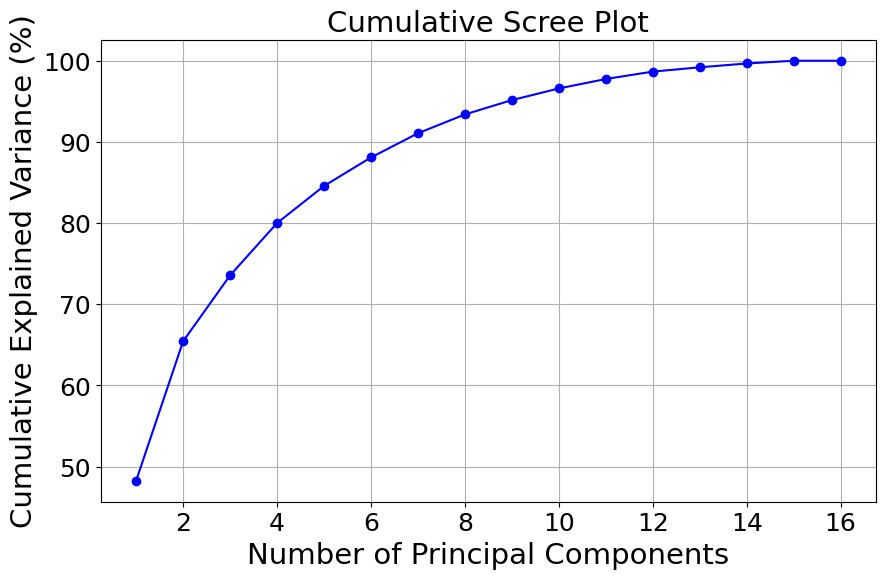

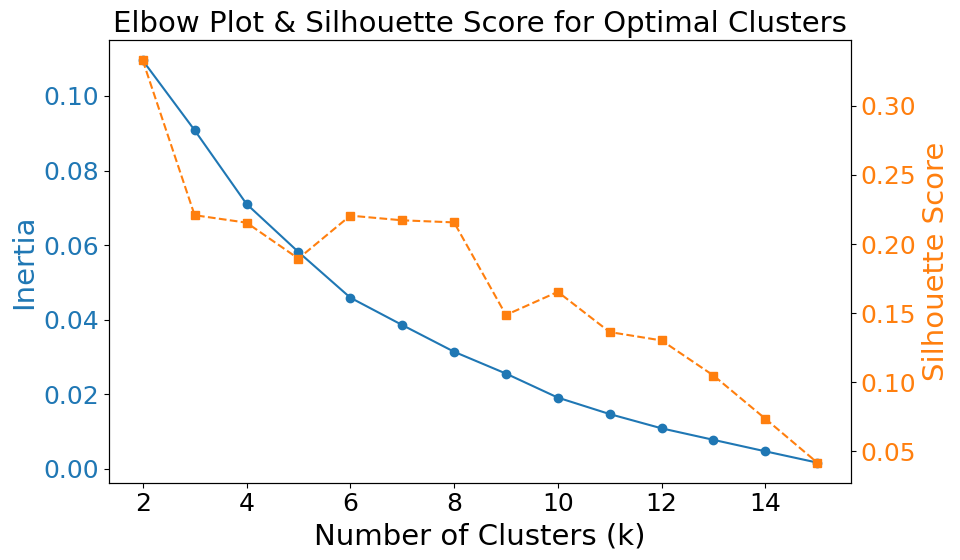

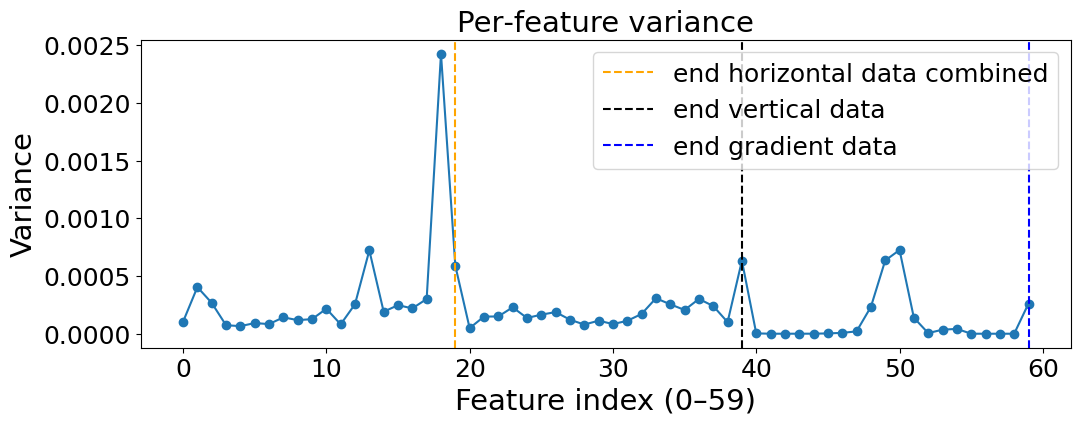

Saved distance plot to: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Clustering Auswertung/175\distances_in_PC_space_Gielow_custom_order.pdf
Saved ordered distances table to: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Clustering Auswertung/175\distances_in_PC_space_Gielow_custom_order.xlsx

Enter pairs of principal components to plot, in the format 'x,y' separated by semicolons.
For example: 1,20; 5,15; 3,7


Enter 3 PC pairs:  1,2


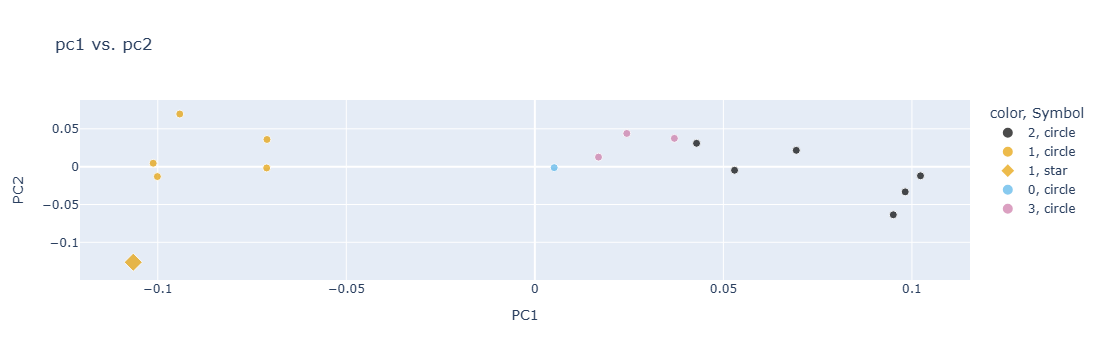

Feature contributions to principal components (PC1 to PC12):


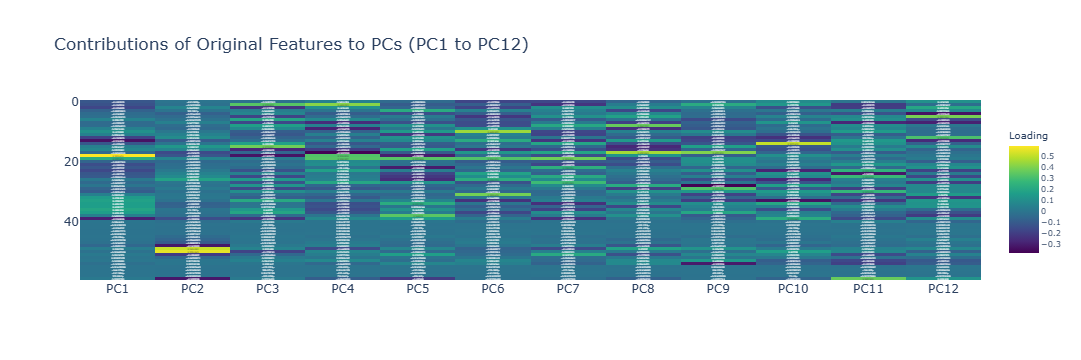

In [13]:
"""
Principal component analysis for the 75% threshold group. Code also computes a cluster analysis afterwards if a user would like to investigate the
results of the respective PCA in that way. The cluster analysis results are however, NOT part of Carl et al. (in prep., 2026). The outcome of this code
utilized in the paper is the bar chart created in the code part "Distance in PC space (relative to reference)"
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import skew, entropy
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px
import plotly.subplots as sp

##############################
# Helper functions for features
##############################

def compute_pdf(series, num_bins=20):
    """Generic PDF without fixed range (for lengths & curvatures)."""
    hist, _ = np.histogram(series, bins=num_bins, density=True)
    if hist.sum() > 0:
        pdf = hist / hist.sum()
    else:
        pdf = np.zeros_like(hist)
    return pdf


def compute_pdf_fixed(series, num_bins=20, bin_range=(-1, 1)):
    """PDF with fixed range (for gradient data)."""
    hist, _ = np.histogram(series, bins=num_bins, range=bin_range, density=True)
    if hist.sum() > 0:
        pdf = hist / hist.sum()
    else:
        pdf = np.zeros_like(hist)
    return pdf



def normalize_feature(series, center_type="mean"):
    if center_type == "mean":
        centered = series - np.mean(series)
    elif center_type == "zero":  # for gradients
        centered = series  # leave zero where it is
    else:
        raise ValueError("Unknown center_type")

    max_val = np.max(np.abs(centered))
    if max_val == 0:
        return centered
    return centered / max_val


def compute_feature_vector(series, num_pdf=20, center_type="mean", fixed_range=False):
    arr = np.array(series, dtype=float)

    finite_vals = arr[np.isfinite(arr)]
    if finite_vals.size > 0:
        max_finite = np.max(finite_vals)
        min_finite = np.min(finite_vals)
        arr = np.where(np.isposinf(arr), max_finite, arr)
        arr = np.where(np.isneginf(arr), min_finite, arr)
    else:
        arr = np.nan_to_num(arr, nan=0.0)

    # Apply chosen centering
    norm_series = normalize_feature(arr, center_type=center_type)

    # Use the right PDF function
    if fixed_range:
        pdf = compute_pdf_fixed(norm_series, num_bins=num_pdf)
    else:
        pdf = compute_pdf(norm_series, num_bins=num_pdf)

    return pdf


##############################
# Loading main (CSV) data and computing features
##############################

def load_main_data(directory, direction):
    datasets = []
    files = sorted(os.listdir(directory))
    for filename in files:
        if filename.endswith('.csv'):
            filepath = os.path.join(directory, filename)
            df = pd.read_csv(filepath)
            if direction == '1st':
                required_columns = ['Horizontal Length', 'Vertical Length']
            elif direction == '2nd':
                required_columns = ['Horizontal Length', 'Vertical Length']  # Will rename below
            missing_columns = [col for col in required_columns if col not in df.columns]
            if missing_columns:
                print(f"Warning: In file '{filepath}', missing columns: {missing_columns}. Skipping.")
                continue
            if direction == '1st':
                df = df[required_columns]
            elif direction == '2nd':
                df = df.rename(columns={'Horizontal Length': 'Horizontal Length Orthogonal'})
                df = df[['Horizontal Length Orthogonal', 'Vertical Length']]
            datasets.append(df)
    if datasets:
        return pd.concat(datasets, ignore_index=True)
    else:
        return pd.DataFrame()

def get_main_features(dataset_dir):
    # Load data from both directions
    dir_1st = os.path.join(dataset_dir, '1st direction')
    dir_2nd = os.path.join(dataset_dir, '2nd direction')
    df1 = load_main_data(dir_1st, '1st')
    df2 = load_main_data(dir_2nd, '2nd')
    
    features = {}
    # Combine Horizontal Length and Horizontal Length Orthogonal into Horizontal Length Combined
    if not df1.empty and not df2.empty:
        combined = np.concatenate([df1['Horizontal Length'].dropna().values, 
                                   df2['Horizontal Length Orthogonal'].dropna().values])
    elif not df1.empty:
        combined = df1['Horizontal Length'].dropna().values
    elif not df2.empty:
        combined = df2['Horizontal Length Orthogonal'].dropna().values
    else:
        combined = np.array([])
    if combined.size > 0:
        features['Horizontal Length Combined'] = compute_feature_vector(combined)
    
    # Combine Vertical Length from both directions
    if not df1.empty and not df2.empty:
        z_combined = pd.concat([df1[['Vertical Length']], df2[['Vertical Length']]], axis=0, ignore_index=True)
        z_combined = pd.DataFrame(z_combined, columns=['Vertical Length'])
        z_values = z_combined['Vertical Length'].dropna().values
    elif not df1.empty:
        z_values = df1['Vertical Length'].dropna().values
    elif not df2.empty:
        z_values = df2['Vertical Length'].dropna().values
    else:
        z_values = np.array([])
    if z_values.size > 0:
        features['Vertical Length'] = compute_feature_vector(z_values)
    return features

##############################
# Loading gradient &  features from Excel files
##############################

def load_grad_data(dataset_name, grad_dir):
    file_path = os.path.join(grad_dir, f"{dataset_name}.xlsx")
    if os.path.isfile(file_path):
        df = pd.read_excel(file_path)
        # Second column: Gradients; third column: 
        gradients = df.iloc[:, 1].dropna().values
        return {'Gradients': gradients}
    else:
        return None

##############################
# Main workflow: Build combined feature matrix and perform clustering
##############################

def main():
    # Use only one base directory.
    base_directory = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Raw data 175"
    
    grad_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Grad & curv\Gradient & curvature Auswertung"
    
    feature_rows = []
    dataset_labels = []
    
   
    dataset_folders = [d for d in os.listdir(base_directory) 
                       if os.path.isdir(os.path.join(base_directory, d))]
    for dataset in dataset_folders:
        dataset_dir = os.path.join(base_directory, dataset)
        dataset_labels.append(dataset)
        
            # Get main features (only use 'Y Length Combined' and 'Z Length')
        main_feats = get_main_features(dataset_dir)
            
            # Load gradient features from Excel file
        grad = load_grad_data(dataset, grad_dir)
        if grad is not None:
            grad_feat = compute_feature_vector(grad['Gradients'], center_type="zero", fixed_range=True)
        else:
            feat_length = 20  # Each PDF vector is of length 20
            grad_feat = np.full(feat_length, np.nan)

            
            # Build the feature vector: use only 'Y Length Combined', 'Z Length', 'Gradients'
        feat_list = []
        expected_keys = ['Horizontal Length Combined', 'Vertical Length']
        missing = []
        for key in expected_keys:
            if key in main_feats:
                feat_list.append(main_feats[key])
            else:
                missing.append(key)
                feat_list.append(np.full(20, np.nan))
            # Add gradient a features
        if np.isnan(grad_feat).any():
            missing.append("Gradients")
        feat_list.append(grad_feat)
        combined_feature_vector = np.concatenate(feat_list)
            
        if np.isnan(combined_feature_vector).any():
            print(f"Skipping dataset {dataset} due to missing features: {', '.join(missing)}")
        else:
            feature_rows.append(combined_feature_vector)
    
    if not feature_rows:
        print("No valid datasets found. Exiting.")
        return
    
    # Build the feature matrix (each row is an 60-element vector)
    feature_matrix = pd.DataFrame(feature_rows, index=dataset_labels)
    print("Feature matrix shape:", feature_matrix.shape)
    output_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\clustering Auswertung\175"
    # --- PCA and Clustering ---
    n_components = min(60, feature_matrix.shape[1], feature_matrix.shape[0])
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(feature_matrix)
    pca_df = pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(n_components)])
    pca_df['Dataset'] = dataset_labels

    # Plot cumulative scree plot (showing cumulative explained variance)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n_components + 1), cumulative_variance * 100, marker='o', color='blue')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance (%)')
    plt.title('Cumulative Scree Plot')
    plt.grid(True)
    plt.savefig(os.path.join(output_dir, 'cumulative_scree_plot.pdf'), format='pdf', dpi=300)
    plt.show()




    # Determine optimal k using elbow plot and silhouette score.
    max_k = min(60, pca_df.shape[0] -1)
    inertia = []
    silhouette_scores = []
    K_range = range(2, max_k + 1)
#cluster plot reproduzierbar (elbow plot nicht)  mit:     kmeans =KMeans(
           # n_clusters=k,
          #  init='k-means++',
            #n_init=10,
           # tol=1e-4,
          #  max_iter=300,
         #   algorithm='elkan',
        #    random_state=16
       # )
    for k in K_range:
        #kmeans = KMeans(n_clusters=k, random_state=19
        #               ) 
        kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        tol=1e-4,
        max_iter=300,
        algorithm='elkan',
        random_state=40)
        

        labels = kmeans.fit_predict(pca_df.select_dtypes(include=[np.number]))
        inertia.append(kmeans.inertia_)
        silhouette_avg = silhouette_score(pca_df.select_dtypes(include=[np.number]), labels)
        silhouette_scores.append(silhouette_avg)

    # Plot Elbow and Silhouette Score
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Inertia', color='tab:blue')
    ax1.plot(K_range, inertia, marker='o', linestyle='-', color='tab:blue', label='Inertia')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax1.twinx()
    ax2.set_ylabel('Silhouette Score', color='tab:orange')
    ax2.plot(K_range, silhouette_scores, marker='s', linestyle='--', color='tab:orange', label='Silhouette Score')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    plt.title('Elbow Plot & Silhouette Score for Optimal Clusters')
    fig.tight_layout()
    plt.savefig(os.path.join(output_dir, 'elbow_silhouette_plot.pdf'), format='pdf', dpi=300)
    plt.show()

    variances = feature_matrix.var(axis=0)
    plt.figure(figsize=(12,4))
    plt.plot(variances, marker='o')
    plt.axvline(19, color='orange', linestyle='--', label='end horizontal data combined')
    plt.axvline(39, color='black', linestyle='--', label='end vertical data')
    plt.axvline(59, color='blue', linestyle='--', label='end gradient data')
    plt.legend()
    plt.ylabel('Variance')
    plt.xlabel('Feature index (0–59)')
    plt.title('Per‑feature variance')
    plt.savefig(os.path.join(output_dir, 'Per‑feature variance.pdf'), format='pdf', dpi=300)
    plt.show()





    best_k = 4  # Manually set number of clusters
    kmeans = KMeans(n_clusters=4, random_state=40)#rs=42
    
    clusters = kmeans.fit_predict(pca_df.select_dtypes(include=[np.number]))
    pca_df['Cluster'] = clusters

    # ---------------------------
    # Distance in PC space (relative to reference)
    # ---------------------------
    dist_output_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Clustering Auswertung/175"
    os.makedirs(dist_output_dir, exist_ok=True)

    reference_name = "Juliusburg_Koestorf-Rosenthal_initial"
    pc_columns = [f"PC{i+1}" for i in range(n_components)]

    coords = pca_df[pc_columns].to_numpy()
    datasets = pca_df['Dataset'].tolist()

    try:
        ref_idx = datasets.index(reference_name)
    except ValueError:
        print(f"Reference dataset '{reference_name}' not found.")
        ref_idx = None

    if ref_idx is not None:
        ref_vec = coords[ref_idx]

        distances_list = []

        for i, (name, vec) in enumerate(zip(datasets, coords)):
            if name == reference_name:
                continue  # <-- exclude reference dataset entirely
            dist = np.linalg.norm(vec - ref_vec)
            distances_list.append((name, dist))

        # Build dataframe and sort ascending
        dist_df = pd.DataFrame(distances_list, columns=['Dataset', 'Distance'])
        # ---------------------------
        # Customize & plot distances (replacement block)
        # ---------------------------
        
        import re
        FONT_SIZE = 20

        # Update rcParams so axes labels, ticks, titles, legend, etc. use the bigger size
        plt.rcParams.update({
            'font.size': FONT_SIZE,
            'axes.titlesize': FONT_SIZE + 1,
            'axes.labelsize': FONT_SIZE + 1,
            'xtick.labelsize': FONT_SIZE - 2,
            'ytick.labelsize': FONT_SIZE - 2,
            'legend.fontsize': FONT_SIZE - 2,
            'figure.titlesize': FONT_SIZE + 1
        })
        # order you requested (canonical form used for ordering)
        order_labels = [
            "10 s 10 b",
            "10 s 0 b",
            "8 s 8 b",
            "5 s 5 b",
            "4 s 4 b",
            "0 s 10 b",
            "3 s 3 b",
            "3 s 2 b",
            "3 s 1 b",
            "2 s 3 b",
            "2 s 2 b",
            "2 s 1 b",
            "1 s 3 b",
            "1 s 2 b",
            "1 s 1 b",
        ]
        
        def extract_config_key(dataset_name):
            """
            Turn dataset names like:
              '4 sections 4 boreholes_hull_GE_150_smoothed'
            into canonical keys like:
              '4 s 4 b'
            Falls back to the first two numbers found if exact phrase not present.
            """
            s = str(dataset_name)
            m = re.search(r"(\d+)\s*sections\s*(\d+)\s*boreholes", s, flags=re.IGNORECASE)
            if m:
                return f"{int(m.group(1))} s {int(m.group(2))} b"
            # fallback: two numbers anywhere in the string
            nums = re.findall(r"(\d+)", s)
            if len(nums) >= 2:
                return f"{int(nums[0])} s {int(nums[1])} b"
                return s  # give up — return original
        
        def display_label_from_key(key):
            """
            Convert canonical key '4 s 4 b' -> compact display '4s 4b'
            """
            m = re.match(r"(\d+)\s*s\s*(\d+)\s*b", str(key))
            if m:
             #   return f"{m.group(1)}s {m.group(2)}b"
                return str(key)
        
        # Build a DataFrame of distances (unsorted)
        dist_df = pd.DataFrame(distances_list, columns=['Dataset', 'Distance'])
        
        # Add canonical config key and display label
        dist_df['ConfigKey'] = dist_df['Dataset'].apply(extract_config_key)
        dist_df['DisplayLabel'] = dist_df['ConfigKey'].apply(display_label_from_key)
        
        # Reorder rows according to order_labels (preserve datasets not in list at the end)
        ordered_rows = []
        seen = set()
        for key in order_labels:
            matches = dist_df[dist_df['ConfigKey'] == key]
            if not matches.empty:
                for _, r in matches.iterrows():
                    ordered_rows.append(r)
                    seen.add(r['Dataset'])
        
        # append any remaining datasets not matched by order_labels
        for _, r in dist_df.iterrows():
            if r['Dataset'] not in seen:
                ordered_rows.append(r)
        
        if not ordered_rows:
            raise RuntimeError("No distances to plot after ordering step.")
        
        final_df = pd.DataFrame(ordered_rows).reset_index(drop=True)
        import json

        with open("plot_config.json") as f:
            ytop = json.load(f)["ytop"]
        # Plot: orange bars, black edge
        plt.figure(figsize=(12, 6))
        x = range(len(final_df))
        #plt.bar(x, final_df['Distance'], color='orange', edgecolor='black')
        bars = plt.bar(x, final_df['Distance'], color='orange', edgecolor='black')
        # X tick labels -> compact labels, rotate for readability
        plt.xticks(x, final_df['DisplayLabel'], rotation=90, ha='right')
        
        ymin, ymax = plt.ylim()
        # offset as a fraction of the data range
        offset = (final_df['Distance'].max() - final_df['Distance'].min()) * 0.02 if final_df['Distance'].max() != final_df['Distance'].min() else 0.01
        for bar, val in zip(bars, final_df['Distance']):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                val,
                f"{val:.3f}",
                ha='center',
                va='bottom',
                rotation=45,
                fontsize=15,
                color='black'
            )

        plt.ylim(0, ytop)
        # Horizontal green mean line
        mean_val = final_df['Distance'].mean()
        plt.axhline(mean_val, color='green', linestyle='--', linewidth=1.5, label=f"Mean = {mean_val:.3f}")
        # Put the mean text near top-right inside axes
        plt.text(0.99, 0.99, f"Mean: {mean_val:.3f}", transform=plt.gca().transAxes,
                 ha="right", va="top", fontsize=18, color='green')
        
        plt.ylabel('Euclidean distance in PC space')
        plt.xlabel('Dataset configuration')
        plt.title(f"Distances in PC space - Threshold 75%")
        plt.tight_layout()
        
        # Save
        pdf_path = os.path.join(dist_output_dir, "distances_in_PC_space_Juliusburg_Koestorf-Rosenthal_custom_order.pdf")
        plt.savefig(pdf_path, format='pdf')
        plt.close()
        print(f"Saved distance plot to: {pdf_path}")
        
        # Also re-save the ordered distances as Excel for reproducibility
        excel_path = os.path.join(dist_output_dir, "distances_in_PC_space_Juliusburg_Koestorf-Rosenthal_custom_order.xlsx")
        final_df[['Dataset','ConfigKey','DisplayLabel','Distance']].to_excel(excel_path, index=False)
        print(f"Saved ordered distances table to: {excel_path}")



    
    output_excel = os.path.join(r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\clustering Auswertung", 'cluster_assignments_P3.xlsx')
    #save_cluster_assignments(pca_df, output_excel)
    
    #dark_colors = ['#1f77b4', '#ff7f0e','#ffb691', '#2ca02c', '#d62728', '#9467bd', 
     #          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    #dark_colors = ['#1f77b4',   '#d62728',  '#7f7f7f', '#ff7f0e', '#9467bd',
               #'#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',  '#2ca02c'] #'#fff3234',
    #dark_colors = [   'rgb(0,0,0)','rgb(230,159,0)','rgb(86, 180, 233)','rgb(0, 114, 178)','rgb(0, 158, 115)','rgb(213, 94, 0)','rgb(204, 121, 167)','rgb(240, 228, 66)' ]
    
    
    raw_colors = [
    (0, 0, 0),
    (230, 159, 0),
    (86, 180, 233),
    (204, 121, 167),
    (0, 158, 115),
    (213, 94, 0),
    (0, 114, 178),
    (240, 228, 66)
]

   # dark_colors = [(r/255, g/255, b/255) for r, g, b in raw_colors]
    
    
  #  selected_colors = dark_colors[:5]
    selected_colors = [mcolors.to_hex((r/255, g/255, b/255)) for r, g, b in raw_colors] 

    # ---------------------------
    # Interactive PC Diagram Selection
    # ---------------------------
    # Ask the user to input three PC pairs to plot
    print("\nEnter pairs of principal components to plot, in the format 'x,y' separated by semicolons.")
    print("For example: 1,20; 5,15; 3,7")
    input_str = input("Enter 3 PC pairs: ")
    # Split by semicolon, then parse each pair
    pairs = [pair.strip() for pair in input_str.split(';') if pair.strip()]
    scatter_plots = []
    for pair in pairs:
        try:
            pc1, pc2 = [int(x.strip()) for x in pair.split(',')]
            # Validate the PC indices (they should be between 1 and n_components)
            if pc1 < 1 or pc2 < 1 or pc1 > n_components or pc2 > n_components:
                print(f"Invalid PC indices in pair '{pair}'. Valid indices are between 1 and {n_components}. Skipping this pair.")
                continue
            highlighted_datasets = {
                "Juliusburg_Koestorf-Rosenthal_initial"
            }
            
            # Define marker styles
            marker_symbols = []
            marker_sizes = []
            
            for name in pca_df['Dataset']:
                if name in highlighted_datasets:
                    marker_symbols.append('star')
                    marker_sizes.append(14)  # larger size for stars
                else:
                    marker_symbols.append('circle')
                    marker_sizes.append(8)   # default circle size
            
            # Add marker info to DataFrame
            pca_df['Symbol'] = marker_symbols
            pca_df['Size'] = marker_sizes
            
            # Use Plotly Express scatter with custom symbols and sizes
            fig = px.scatter(
                pca_df, 
                x=f'PC{pc1}', 
                y=f'PC{pc2}', 
                color=pca_df['Cluster'].astype(str),
                hover_name='Dataset', 
                symbol='Symbol',
                size='Size',
                color_discrete_sequence=selected_colors,
                title=f'pc{pc1} vs. pc{pc2}',
            )
            
            # Fix marker size scaling (size is exact, not scaled by data range)
            fig.update_traces(marker=dict(sizemode='diameter', sizeref=1, sizemin=1))
            
            scatter_plots.append(fig)
        except Exception as e:
            print(f"Error processing pair '{pair}': {e}")
    
    # Display each scatter plot
    for fig in scatter_plots:
        fig.show()
    
        # ---------------------------
    # Contribution graph for PCs 1 to 12
    # ---------------------------
    contrib_components = min(12, n_components)
    contributions = pd.DataFrame(
        pca.components_.T[:, :contrib_components],
        index=feature_matrix.columns,
        columns=[f'PC{i+1}' for i in range(contrib_components)]
    )

    print("Feature contributions to principal components (PC1 to PC12):")
    #print(contributions)

    # plotly heatmap
    fig = px.imshow(
        contributions,
        text_auto=True,
        aspect="auto",
        title="Contributions of Original Features to PCs (PC1 to PC12)",
        color_continuous_scale='Viridis'
    )

    # add more ticks on the colorbar
    fig.update_coloraxes(colorbar=dict(
        title="Loading",
        tickmode='linear',
        tick0=0.0,
        dtick=0.10,     # a tick every 0.05 units
        tickfont=dict(size=8),
        lenmode='fraction',
        len=0.8
    ))

    fig.show()
    #fig.write_image(os.path.join(output_dir, 'pc_contributions_heatmap.pdf'), format='pdf', scale=3)


if __name__ == "__main__":
    main()

Feature matrix shape: (15, 60)


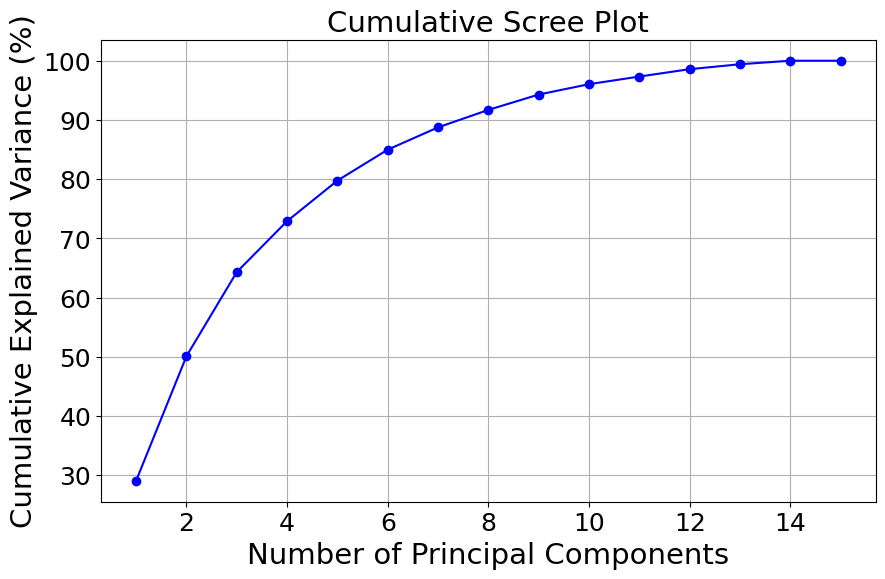

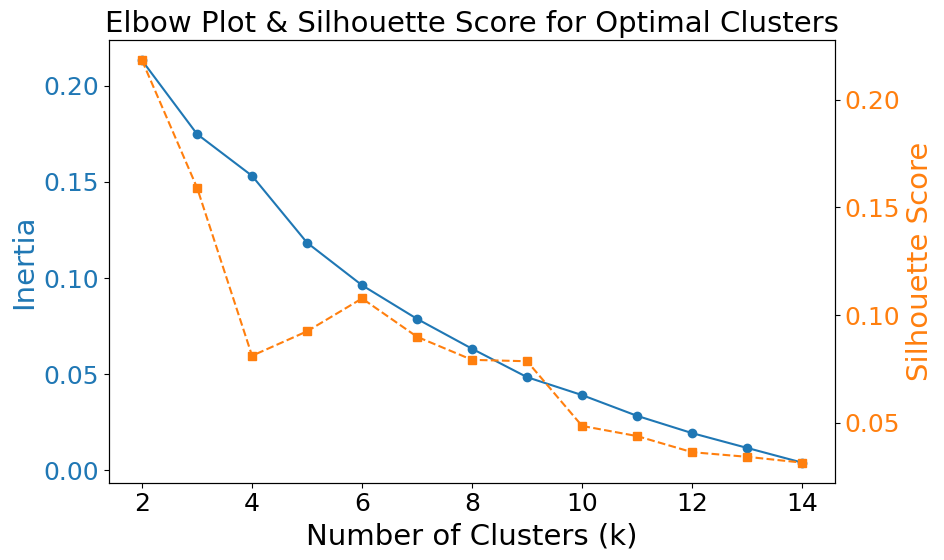

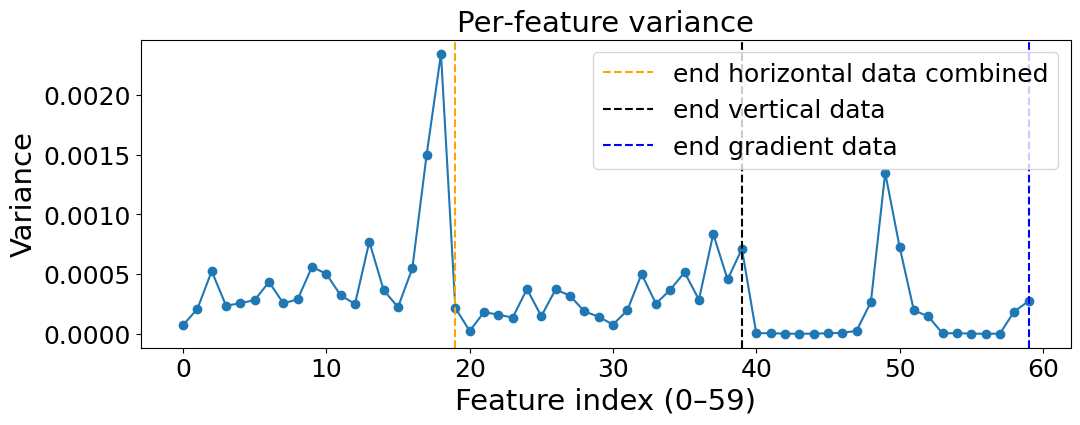

Saved distance plot to: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Clustering Auswertung/199\distances_in_PC_space_Gielow_custom_order.pdf
Saved ordered distances table to: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Gielow\Clustering Auswertung/199\distances_in_PC_space_Gielow_custom_order.xlsx

Enter pairs of principal components to plot, in the format 'x,y' separated by semicolons.
For example: 1,20; 5,15; 3,7


Enter 3 PC pairs:  1,2


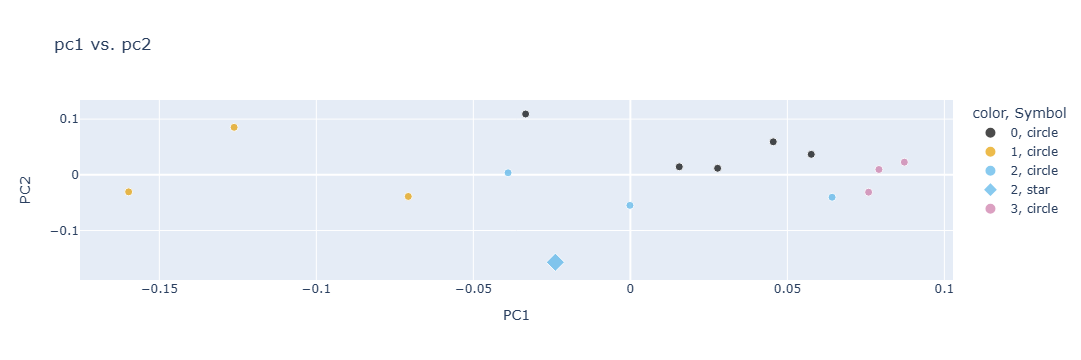

Feature contributions to principal components (PC1 to PC12):


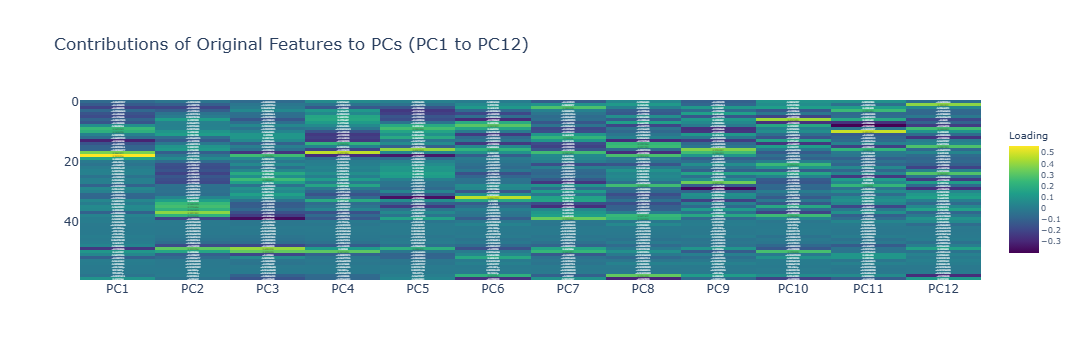

In [14]:
"""
Principal component analysis for the 01% threshold group. Code also computes a cluster analysis afterwards if a user would like to investigate the
results of the respective PCA in that way. The cluster analysis results are however, NOT part of Carl et al. (in prep., 2026). The outcome of this code
utilized in the paper is the bar chart created in the code part "Distance in PC space (relative to reference)"
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import skew, entropy
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px
import plotly.subplots as sp

##############################
# Helper functions for features
##############################

def compute_pdf(series, num_bins=20):
    """Generic PDF without fixed range (for lengths & curvatures)."""
    hist, _ = np.histogram(series, bins=num_bins, density=True)
    if hist.sum() > 0:
        pdf = hist / hist.sum()
    else:
        pdf = np.zeros_like(hist)
    return pdf


def compute_pdf_fixed(series, num_bins=20, bin_range=(-1, 1)):
    """PDF with fixed range (for gradient data)."""
    hist, _ = np.histogram(series, bins=num_bins, range=bin_range, density=True)
    if hist.sum() > 0:
        pdf = hist / hist.sum()
    else:
        pdf = np.zeros_like(hist)
    return pdf



def normalize_feature(series, center_type="mean"):
    if center_type == "mean":
        centered = series - np.mean(series)
    elif center_type == "zero":  # for gradients
        centered = series  # leave zero where it is
    else:
        raise ValueError("Unknown center_type")

    max_val = np.max(np.abs(centered))
    if max_val == 0:
        return centered
    return centered / max_val


def compute_feature_vector(series, num_pdf=20, center_type="mean", fixed_range=False):
    arr = np.array(series, dtype=float)

    finite_vals = arr[np.isfinite(arr)]
    if finite_vals.size > 0:
        max_finite = np.max(finite_vals)
        min_finite = np.min(finite_vals)
        arr = np.where(np.isposinf(arr), max_finite, arr)
        arr = np.where(np.isneginf(arr), min_finite, arr)
    else:
        arr = np.nan_to_num(arr, nan=0.0)

    # Apply chosen centering
    norm_series = normalize_feature(arr, center_type=center_type)

    # Use the right PDF function
    if fixed_range:
        pdf = compute_pdf_fixed(norm_series, num_bins=num_pdf)
    else:
        pdf = compute_pdf(norm_series, num_bins=num_pdf)

    return pdf


##############################
# Loading main (CSV) data and computing features
##############################

def load_main_data(directory, direction):
    datasets = []
    files = sorted(os.listdir(directory))
    for filename in files:
        if filename.endswith('.csv'):
            filepath = os.path.join(directory, filename)
            df = pd.read_csv(filepath)
            if direction == '1st':
                required_columns = ['Horizontal Length', 'Vertical Length']
            elif direction == '2nd':
                required_columns = ['Horizontal Length', 'Vertical Length']  # Will rename below
            missing_columns = [col for col in required_columns if col not in df.columns]
            if missing_columns:
                print(f"Warning: In file '{filepath}', missing columns: {missing_columns}. Skipping.")
                continue
            if direction == '1st':
                df = df[required_columns]
            elif direction == '2nd':
                df = df.rename(columns={'Horizontal Length': 'Horizontal Length Orthogonal'})
                df = df[['Horizontal Length Orthogonal', 'Vertical Length']]
            datasets.append(df)
    if datasets:
        return pd.concat(datasets, ignore_index=True)
    else:
        return pd.DataFrame()

def get_main_features(dataset_dir):
    # Load data from both directions
    dir_1st = os.path.join(dataset_dir, '1st direction')
    dir_2nd = os.path.join(dataset_dir, '2nd direction')
    df1 = load_main_data(dir_1st, '1st')
    df2 = load_main_data(dir_2nd, '2nd')
    
    features = {}
    # Combine Horizontal Length and Horizontal Length Orthogonal into Horizontal Length Combined
    if not df1.empty and not df2.empty:
        combined = np.concatenate([df1['Horizontal Length'].dropna().values, 
                                   df2['Horizontal Length Orthogonal'].dropna().values])
    elif not df1.empty:
        combined = df1['Horizontal Length'].dropna().values
    elif not df2.empty:
        combined = df2['Horizontal Length Orthogonal'].dropna().values
    else:
        combined = np.array([])
    if combined.size > 0:
        features['Horizontal Length Combined'] = compute_feature_vector(combined)
    
    # Combine Vertical Length from both directions
    if not df1.empty and not df2.empty:
        z_combined = pd.concat([df1[['Vertical Length']], df2[['Vertical Length']]], axis=0, ignore_index=True)
        z_combined = pd.DataFrame(z_combined, columns=['Vertical Length'])
        z_values = z_combined['Vertical Length'].dropna().values
    elif not df1.empty:
        z_values = df1['Vertical Length'].dropna().values
    elif not df2.empty:
        z_values = df2['Vertical Length'].dropna().values
    else:
        z_values = np.array([])
    if z_values.size > 0:
        features['Vertical Length'] = compute_feature_vector(z_values)
    return features

##############################
# Loading gradient &  features from Excel files
##############################

def load_grad_data(dataset_name, grad_dir):
    file_path = os.path.join(grad_dir, f"{dataset_name}.xlsx")
    if os.path.isfile(file_path):
        df = pd.read_excel(file_path)
        # Second column: Gradients; third column: 
        gradients = df.iloc[:, 1].dropna().values
        return {'Gradients': gradients}
    else:
        return None

##############################
# Main workflow: Build combined feature matrix and perform clustering
##############################

def main():
    # Use only one base directory.
    base_directory = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Structural dimensions\Raw data 199"
    
    grad_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Grad & curv\Gradient & curvature Auswertung"
    
    feature_rows = []
    dataset_labels = []
    
   
    dataset_folders = [d for d in os.listdir(base_directory) 
                       if os.path.isdir(os.path.join(base_directory, d))]
    for dataset in dataset_folders:
        dataset_dir = os.path.join(base_directory, dataset)
        dataset_labels.append(dataset)
        
            # Get main features (only use 'Y Length Combined' and 'Z Length')
        main_feats = get_main_features(dataset_dir)
            
            # Load gradient features from Excel file
        grad = load_grad_data(dataset, grad_dir)
        if grad is not None:
            grad_feat = compute_feature_vector(grad['Gradients'], center_type="zero", fixed_range=True)
        else:
            feat_length = 20  # Each PDF vector is of length 20
            grad_feat = np.full(feat_length, np.nan)

            
            # Build the feature vector: use only 'Y Length Combined', 'Z Length', 'Gradients'
        feat_list = []
        expected_keys = ['Horizontal Length Combined', 'Vertical Length']
        missing = []
        for key in expected_keys:
            if key in main_feats:
                feat_list.append(main_feats[key])
            else:
                missing.append(key)
                feat_list.append(np.full(20, np.nan))
            # Add gradient a features
        if np.isnan(grad_feat).any():
            missing.append("Gradients")
        feat_list.append(grad_feat)
        combined_feature_vector = np.concatenate(feat_list)
            
        if np.isnan(combined_feature_vector).any():
            print(f"Skipping dataset {dataset} due to missing features: {', '.join(missing)}")
        else:
            feature_rows.append(combined_feature_vector)
    
    if not feature_rows:
        print("No valid datasets found. Exiting.")
        return
    
    # Build the feature matrix (each row is an 60-element vector)
    feature_matrix = pd.DataFrame(feature_rows, index=dataset_labels)
    print("Feature matrix shape:", feature_matrix.shape)
    output_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\clustering Auswertung\199"
    # --- PCA and Clustering ---
    n_components = min(60, feature_matrix.shape[1], feature_matrix.shape[0])
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(feature_matrix)
    pca_df = pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(n_components)])
    pca_df['Dataset'] = dataset_labels

    # Plot cumulative scree plot (showing cumulative explained variance)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n_components + 1), cumulative_variance * 100, marker='o', color='blue')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance (%)')
    plt.title('Cumulative Scree Plot')
    plt.grid(True)
    plt.savefig(os.path.join(output_dir, 'cumulative_scree_plot.pdf'), format='pdf', dpi=300)
    plt.show()




    # Determine optimal k using elbow plot and silhouette score.
    max_k = min(60, pca_df.shape[0] -1)
    inertia = []
    silhouette_scores = []
    K_range = range(2, max_k + 1)
#cluster plot reproduzierbar (elbow plot nicht)  mit:     kmeans =KMeans(
           # n_clusters=k,
          #  init='k-means++',
            #n_init=10,
           # tol=1e-4,
          #  max_iter=300,
         #   algorithm='elkan',
        #    random_state=16
       # )
    for k in K_range:
        #kmeans = KMeans(n_clusters=k, random_state=19
        #               ) 
        kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        tol=1e-4,
        max_iter=300,
        algorithm='elkan',
        random_state=40)
        

        labels = kmeans.fit_predict(pca_df.select_dtypes(include=[np.number]))
        inertia.append(kmeans.inertia_)
        silhouette_avg = silhouette_score(pca_df.select_dtypes(include=[np.number]), labels)
        silhouette_scores.append(silhouette_avg)

    # Plot Elbow and Silhouette Score
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Inertia', color='tab:blue')
    ax1.plot(K_range, inertia, marker='o', linestyle='-', color='tab:blue', label='Inertia')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax1.twinx()
    ax2.set_ylabel('Silhouette Score', color='tab:orange')
    ax2.plot(K_range, silhouette_scores, marker='s', linestyle='--', color='tab:orange', label='Silhouette Score')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    plt.title('Elbow Plot & Silhouette Score for Optimal Clusters')
    fig.tight_layout()
    plt.savefig(os.path.join(output_dir, 'elbow_silhouette_plot.pdf'), format='pdf', dpi=300)
    plt.show()

    variances = feature_matrix.var(axis=0)
    plt.figure(figsize=(12,4))
    plt.plot(variances, marker='o')
    plt.axvline(19, color='orange', linestyle='--', label='end horizontal data combined')
    plt.axvline(39, color='black', linestyle='--', label='end vertical data')
    plt.axvline(59, color='blue', linestyle='--', label='end gradient data')
    plt.legend()
    plt.ylabel('Variance')
    plt.xlabel('Feature index (0–59)')
    plt.title('Per‑feature variance')
    plt.savefig(os.path.join(output_dir, 'Per‑feature variance.pdf'), format='pdf', dpi=300)
    plt.show()





    best_k = 4  # Manually set number of clusters
    kmeans = KMeans(n_clusters=4, random_state=40)#rs=42
    
    clusters = kmeans.fit_predict(pca_df.select_dtypes(include=[np.number]))
    pca_df['Cluster'] = clusters

    # ---------------------------
    # Distance in PC space (relative to reference)
    # ---------------------------
    dist_output_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Clustering Auswertung/199"
    os.makedirs(dist_output_dir, exist_ok=True)

    reference_name = "Juliusburg_Koestorf-Rosenthal_initial"
    pc_columns = [f"PC{i+1}" for i in range(n_components)]

    coords = pca_df[pc_columns].to_numpy()
    datasets = pca_df['Dataset'].tolist()

    try:
        ref_idx = datasets.index(reference_name)
    except ValueError:
        print(f"Reference dataset '{reference_name}' not found.")
        ref_idx = None

    if ref_idx is not None:
        ref_vec = coords[ref_idx]

        distances_list = []

        for i, (name, vec) in enumerate(zip(datasets, coords)):
            if name == reference_name:
                continue  # <-- exclude reference dataset entirely
            dist = np.linalg.norm(vec - ref_vec)
            distances_list.append((name, dist))

        # Build dataframe and sort ascending
        dist_df = pd.DataFrame(distances_list, columns=['Dataset', 'Distance'])
        # ---------------------------
        # Customize & plot distances (replacement block)
        # ---------------------------
        
        import re
        FONT_SIZE = 20

        # Update rcParams so axes labels, ticks, titles, legend, etc. use the bigger size
        plt.rcParams.update({
            'font.size': FONT_SIZE,
            'axes.titlesize': FONT_SIZE + 1,
            'axes.labelsize': FONT_SIZE + 1,
            'xtick.labelsize': FONT_SIZE - 2,
            'ytick.labelsize': FONT_SIZE - 2,
            'legend.fontsize': FONT_SIZE - 2,
            'figure.titlesize': FONT_SIZE + 1
        })
        
        order_labels = [
            "10 s 10 b",
            "10 s 0 b",
            "8 s 8 b",
            "5 s 5 b",
            "4 s 4 b",
            "0 s 10 b",
            "3 s 3 b",
            "3 s 2 b",
            "3 s 1 b",
            "2 s 3 b",
            "2 s 2 b",
            "2 s 1 b",
            "1 s 3 b",
            "1 s 2 b",
            "1 s 1 b",
        ]
        
        def extract_config_key(dataset_name):
            """
            Turn dataset names like:
              '4 sections 4 boreholes_hull_GE_150_smoothed'
            into canonical keys like:
              '4 s 4 b'
            Falls back to the first two numbers found if exact phrase not present.
            """
            s = str(dataset_name)
            m = re.search(r"(\d+)\s*sections\s*(\d+)\s*boreholes", s, flags=re.IGNORECASE)
            if m:
                return f"{int(m.group(1))} s {int(m.group(2))} b"
            # fallback: two numbers anywhere in the string
            nums = re.findall(r"(\d+)", s)
            if len(nums) >= 2:
                return f"{int(nums[0])} s {int(nums[1])} b"
                return s  # give up — return original
        
        def display_label_from_key(key):
            """
            Convert canonical key '4 s 4 b' -> compact display '4s 4b'
            """
            m = re.match(r"(\d+)\s*s\s*(\d+)\s*b", str(key))
            if m:
             #   return f"{m.group(1)}s {m.group(2)}b"
                return str(key)
        
        # Build a DataFrame of distances (unsorted)
        dist_df = pd.DataFrame(distances_list, columns=['Dataset', 'Distance'])
        
        # Add canonical config key and display label
        dist_df['ConfigKey'] = dist_df['Dataset'].apply(extract_config_key)
        dist_df['DisplayLabel'] = dist_df['ConfigKey'].apply(display_label_from_key)
        
        # Reorder rows according to order_labels (preserve datasets not in list at the end)
        ordered_rows = []
        seen = set()
        for key in order_labels:
            matches = dist_df[dist_df['ConfigKey'] == key]
            if not matches.empty:
                for _, r in matches.iterrows():
                    ordered_rows.append(r)
                    seen.add(r['Dataset'])
        
        # append any remaining datasets not matched by order_labels
        for _, r in dist_df.iterrows():
            if r['Dataset'] not in seen:
                ordered_rows.append(r)
        
        if not ordered_rows:
            raise RuntimeError("No distances to plot after ordering step.")
        
        final_df = pd.DataFrame(ordered_rows).reset_index(drop=True)
        import json

        with open("plot_config.json") as f:
            ytop = json.load(f)["ytop"]
        # Plot: orange bars, black edge
        plt.figure(figsize=(12, 6))
        x = range(len(final_df))
       # plt.bar(x, final_df['Distance'], color='orange', edgecolor='black')
        bars = plt.bar(x, final_df['Distance'], color='orange', edgecolor='black')
        # X tick labels -> compact labels, rotate for readability
        plt.xticks(x, final_df['DisplayLabel'], rotation=90, ha='right')
        
        # Add numeric values above each bar
        ymin, ymax = plt.ylim()
        # offset as a fraction of the data range
        offset = (final_df['Distance'].max() - final_df['Distance'].min()) * 0.02 if final_df['Distance'].max() != final_df['Distance'].min() else 0.01
        for bar, val in zip(bars, final_df['Distance']):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                val,
                f"{val:.3f}",
                ha='center',
                va='bottom',
                rotation=45,
                fontsize=15,
                color='black'
            )

        plt.ylim(0, ytop)
        # Horizontal green mean line
        mean_val = final_df['Distance'].mean()
        plt.axhline(mean_val, color='green', linestyle='--', linewidth=1.5, label=f"Mean = {mean_val:.3f}")
        # Put the mean text near top-right inside axes
        plt.text(0.99, 0.99, f"Mean: {mean_val:.3f}", transform=plt.gca().transAxes,
                 ha="right", va="top", fontsize=18, color='green')
        
        plt.ylabel('Euclidean distance in PC space')
        plt.xlabel('Dataset configuration')
        plt.title(f"Distances in PC space - Threshold 99%")
        plt.tight_layout()
        #plt.tight_layout(rect=[0, 0, 1, 0.95])

        # Save
        pdf_path = os.path.join(dist_output_dir, "distances_in_PC_space_Juliusburg_Koestorf-Rosenthal_custom_order.pdf")
        plt.savefig(pdf_path, format='pdf')
        plt.close()
        print(f"Saved distance plot to: {pdf_path}")
        
        # Also re-save the ordered distances as Excel for reproducibility
        excel_path = os.path.join(dist_output_dir, "distances_in_PC_space_Juliusburg_Koestorf-Rosenthal_custom_order.xlsx")
        final_df[['Dataset','ConfigKey','DisplayLabel','Distance']].to_excel(excel_path, index=False)
        print(f"Saved ordered distances table to: {excel_path}")
    

    output_excel = os.path.join(r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\clustering Auswertung", 'cluster_assignments_P3.xlsx')
    #save_cluster_assignments(pca_df, output_excel)
    
    #dark_colors = ['#1f77b4', '#ff7f0e','#ffb691', '#2ca02c', '#d62728', '#9467bd', 
     #          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    #dark_colors = ['#1f77b4',   '#d62728',  '#7f7f7f', '#ff7f0e', '#9467bd',
               #'#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',  '#2ca02c'] #'#fff3234',
    #dark_colors = [   'rgb(0,0,0)','rgb(230,159,0)','rgb(86, 180, 233)','rgb(0, 114, 178)','rgb(0, 158, 115)','rgb(213, 94, 0)','rgb(204, 121, 167)','rgb(240, 228, 66)' ]
    
    
    raw_colors = [
    (0, 0, 0),
    (230, 159, 0),
    (86, 180, 233),
    (204, 121, 167),
    (0, 158, 115),
    (213, 94, 0),
    (0, 114, 178),
    (240, 228, 66)
]

   # dark_colors = [(r/255, g/255, b/255) for r, g, b in raw_colors]
    
    
  #  selected_colors = dark_colors[:5]
    selected_colors = [mcolors.to_hex((r/255, g/255, b/255)) for r, g, b in raw_colors] 

    # ---------------------------
    # Interactive PC Diagram Selection
    # ---------------------------
    # Ask the user to input three PC pairs to plot
    print("\nEnter pairs of principal components to plot, in the format 'x,y' separated by semicolons.")
    print("For example: 1,20; 5,15; 3,7")
    input_str = input("Enter 3 PC pairs: ")
    # Split by semicolon, then parse each pair
    pairs = [pair.strip() for pair in input_str.split(';') if pair.strip()]
    scatter_plots = []
    for pair in pairs:
        try:
            pc1, pc2 = [int(x.strip()) for x in pair.split(',')]
            # Validate the PC indices (they should be between 1 and n_components)
            if pc1 < 1 or pc2 < 1 or pc1 > n_components or pc2 > n_components:
                print(f"Invalid PC indices in pair '{pair}'. Valid indices are between 1 and {n_components}. Skipping this pair.")
                continue
            highlighted_datasets = {
                "Juliusburg_Koestorf-Rosenthal_initial"
            }
            
            # Define marker styles
            marker_symbols = []
            marker_sizes = []
            
            for name in pca_df['Dataset']:
                if name in highlighted_datasets:
                    marker_symbols.append('star')
                    marker_sizes.append(14)  # larger size for stars
                else:
                    marker_symbols.append('circle')
                    marker_sizes.append(8)   # default circle size
            
            # Add marker info to DataFrame
            pca_df['Symbol'] = marker_symbols
            pca_df['Size'] = marker_sizes
            
            # Use Plotly Express scatter with custom symbols and sizes
            fig = px.scatter(
                pca_df, 
                x=f'PC{pc1}', 
                y=f'PC{pc2}', 
                color=pca_df['Cluster'].astype(str),
                hover_name='Dataset', 
                symbol='Symbol',
                size='Size',
                color_discrete_sequence=selected_colors,
                title=f'pc{pc1} vs. pc{pc2}',
            )
            
            # Fix marker size scaling (size is exact, not scaled by data range)
            fig.update_traces(marker=dict(sizemode='diameter', sizeref=1, sizemin=1))
            
            scatter_plots.append(fig)
        except Exception as e:
            print(f"Error processing pair '{pair}': {e}")
    
    # Display each scatter plot
    for fig in scatter_plots:
        fig.show()
    
        # ---------------------------
    # Contribution graph for PCs 1 to 12
    # ---------------------------
    contrib_components = min(12, n_components)
    contributions = pd.DataFrame(
        pca.components_.T[:, :contrib_components],
        index=feature_matrix.columns,
        columns=[f'PC{i+1}' for i in range(contrib_components)]
    )

    print("Feature contributions to principal components (PC1 to PC12):")
    #print(contributions)

    # plotly heatmap
    fig = px.imshow(
        contributions,
        text_auto=True,
        aspect="auto",
        title="Contributions of Original Features to PCs (PC1 to PC12)",
        color_continuous_scale='Viridis'
    )

    # add more ticks on the colorbar
    fig.update_coloraxes(colorbar=dict(
        title="Loading",
        tickmode='linear',
        tick0=0.0,
        dtick=0.10,     # a tick every 0.05 units
        tickfont=dict(size=8),
        lenmode='fraction',
        len=0.8
    ))

    fig.show()
    #fig.write_image(os.path.join(output_dir, 'pc_contributions_heatmap.pdf'), format='pdf', scale=3)


if __name__ == "__main__":
    main()

In [ ]:
"""
Code to create the lineplot for the mean PC space distance, based on the PCA´s in the previous cells
"""

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# SETTINGS
# ---------------------------------------------------

base_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Clustering Auswertung"
thresholds = [101, 125, 150, 175, 199]
file_name = "distances_in_PC_space_Juliusburg_Koestorf-Rosenthal_custom_order.xlsx"

output_excel = os.path.join(base_dir, "mean_distances_in_PC_space_Juliusburg_Koestorf-Rosenthal.xlsx")
output_pdf = os.path.join(base_dir, "mean_distances_in_PC_space_Juliusburg_Koestorf-Rosenthal.pdf")

# ---------------------------------------------------
# LOAD ALL DISTANCE FILES
# ---------------------------------------------------

all_data = []

for thr in thresholds:
    file_path = os.path.join(base_dir, str(thr), file_name)
    
    if not os.path.isfile(file_path):
        print(f"File not found: {file_path}")
        continue
    
    df = pd.read_excel(file_path)
    df["Threshold"] = thr
    all_data.append(df)

if not all_data:
    print("No valid files found. Exiting.")
    exit()

combined_df = pd.concat(all_data, ignore_index=True)

# ---------------------------------------------------
# EXTRACT DATASET CONFIGURATION
# ---------------------------------------------------

def extract_configuration(name):
    pattern = r"(\d+\s+sections\s+\d+\s+boreholes)"
    match = re.search(pattern, name, re.IGNORECASE)
    if match:
        return match.group(1)
    else:
        return None

combined_df["Configuration"] = combined_df["Dataset"].apply(extract_configuration)

# Remove rows where configuration could not be detected
combined_df = combined_df.dropna(subset=["Configuration"])

# ---------------------------------------------------
# COMPUTE MEAN DISTANCE PER CONFIGURATION
# ---------------------------------------------------

mean_df = (
    combined_df
    .groupby("Configuration")["Distance"]
    .mean()
    .reset_index()
)

# Sort ascending by mean distance
mean_df = mean_df.sort_values("Distance", ascending=True).reset_index(drop=True)

# ---------------------------------------------------
# SAVE MEAN VALUES TO EXCEL
# ---------------------------------------------------

mean_df.to_excel(output_excel, index=False)
print(f"Saved mean distances to: {output_excel}")

# ---------------------------------------------------
# RENAME LABELS TO "x s y b"
# ---------------------------------------------------

def short_label(config_string):
    m = re.match(r"(\d+)\s+sections\s+(\d+)\s+boreholes", config_string, re.IGNORECASE)
    if m:
        return f"{m.group(1)} s {m.group(2)} b"
    return config_string

mean_df["ShortLabel"] = mean_df["Configuration"].apply(short_label)

# ---------------------------------------------------
# CREATE SORTED LINE PLOT (VECTOR PDF)
# ---------------------------------------------------

FONT_SIZE = 20
plt.rcParams.update({
    'font.size': FONT_SIZE,
    'axes.titlesize': FONT_SIZE + 1,
    'axes.labelsize': FONT_SIZE + 1,
    'xtick.labelsize': FONT_SIZE - 2,
    'ytick.labelsize': FONT_SIZE - 2,
    'legend.fontsize': FONT_SIZE - 2,
    'figure.titlesize': FONT_SIZE + 1
})


plt.figure(figsize=(12, 5))

x = range(len(mean_df))
y = mean_df["Distance"]

# Add some headroom for labels
ymax = y.max()
ymin = y.min()
#plt.ylim(0, ymax * 1.1)

# Orange line plot with markers
plt.plot(x, y, marker="o", linestyle="-", color="orange", linewidth=2)

# X-axis labels (ascending order already ensured)
plt.xticks(x, mean_df["ShortLabel"], rotation=90, ha="center")

# Write values next to each point
offset = (ymax - ymin) * 0.05
label_offset = (ymax - ymin) * 0.015

for i, val in enumerate(y):
    plt.text(
        i,
        val + offset,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=18,
        color="black",
        rotation=45
    )

plt.ylabel("Mean Euclidean distance in PC space")
plt.xlabel("Dataset configuration")
plt.title("Mean Distance in PC Space")
plt.ylim(ymin - offset, ymax + offset * 8)


# Stable margins (avoid tight_layout cropping issues)
plt.subplots_adjust(left=0.12, right=0.98, bottom=0.30, top=0.88)

plt.savefig(output_pdf, format="pdf")
plt.close()

print(f"Saved mean distance plot to: {output_pdf}")


In [4]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# SETTINGS
# ---------------------------------------------------

base_dir = r"C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Clustering Auswertung"
thresholds = [101, 125, 150, 175, 199]
file_name = "distances_in_PC_space_Juliusburg_Koestorf-Rosenthal_custom_order.xlsx"

output_excel = os.path.join(base_dir, "mean_distances_in_PC_space_Juliusburg_Koestorf-Rosenthal.xlsx")
output_pdf = os.path.join(base_dir, "mean_distances_in_PC_space_Juliusburg_Koestorf-Rosenthal.pdf")

# ---------------------------------------------------
# LOAD ALL DISTANCE FILES
# ---------------------------------------------------

all_data = []

for thr in thresholds:
    file_path = os.path.join(base_dir, str(thr), file_name)
    
    if not os.path.isfile(file_path):
        print(f"File not found: {file_path}")
        continue
    
    df = pd.read_excel(file_path)
    df["Threshold"] = thr
    all_data.append(df)

if not all_data:
    print("No valid files found. Exiting.")
    exit()

combined_df = pd.concat(all_data, ignore_index=True)

# ---------------------------------------------------
# EXTRACT DATASET CONFIGURATION
# ---------------------------------------------------
# Example pattern: "10 sections 10 boreholes"
# This regex extracts "<number> sections <number> boreholes"

def extract_configuration(name):
    pattern = r"(\d+\s+sections\s+\d+\s+boreholes)"
    match = re.search(pattern, name, re.IGNORECASE)
    if match:
        return match.group(1)
    else:
        return None

combined_df["Configuration"] = combined_df["Dataset"].apply(extract_configuration)

# Remove rows where configuration could not be detected
combined_df = combined_df.dropna(subset=["Configuration"])

# ---------------------------------------------------
# COMPUTE MEAN DISTANCE PER CONFIGURATION
# ---------------------------------------------------

mean_df = (
    combined_df
    .groupby("Configuration")["Distance"]
    .mean()
    .reset_index()
)

# Sort ascending by mean distance
mean_df = mean_df.sort_values("Distance", ascending=True).reset_index(drop=True)

# ---------------------------------------------------
# SAVE MEAN VALUES TO EXCEL
# ---------------------------------------------------

mean_df.to_excel(output_excel, index=False)
print(f"Saved mean distances to: {output_excel}")

# ---------------------------------------------------
# RENAME LABELS TO "x s y b"
# ---------------------------------------------------

def short_label(config_string):
    m = re.match(r"(\d+)\s+sections\s+(\d+)\s+boreholes", config_string, re.IGNORECASE)
    if m:
        return f"{m.group(1)} s {m.group(2)} b"
    return config_string

mean_df["ShortLabel"] = mean_df["Configuration"].apply(short_label)

# ---------------------------------------------------
# CREATE SORTED LINE PLOT (VECTOR PDF)
# ---------------------------------------------------

FONT_SIZE = 20
plt.rcParams.update({
    'font.size': FONT_SIZE,
    'axes.titlesize': FONT_SIZE + 1,
    'axes.labelsize': FONT_SIZE + 1,
    'xtick.labelsize': FONT_SIZE - 2,
    'ytick.labelsize': FONT_SIZE - 2,
    'legend.fontsize': FONT_SIZE - 2,
    'figure.titlesize': FONT_SIZE + 1
})


plt.figure(figsize=(12, 5))

x = range(len(mean_df))
y = mean_df["Distance"]

# Add some headroom for labels
ymax = y.max()
ymin = y.min()
#plt.ylim(0, ymax * 1.1)

# Orange line plot with markers
plt.plot(x, y, marker="o", linestyle="-", color="orange", linewidth=2)

# X-axis labels (ascending order already ensured)
plt.xticks(x, mean_df["ShortLabel"], rotation=90, ha="center")

# Write values next to each point
offset = (ymax - ymin) * 0.05
label_offset = (ymax - ymin) * 0.015

for i, val in enumerate(y):
    plt.text(
        i,
        val + offset,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=18,
        color="black",
        rotation=45
    )

plt.ylabel("Mean Euclidean distance in PC space")
plt.xlabel("Dataset configuration")
plt.title("Mean Distance in PC Space")
plt.ylim(ymin - offset, ymax + offset * 8)


# Stable margins (avoid tight_layout cropping issues)
plt.subplots_adjust(left=0.12, right=0.98, bottom=0.30, top=0.88)

plt.savefig(output_pdf, format="pdf")
plt.close()

print(f"Saved mean distance plot to: {output_pdf}")



Saved mean distances to: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Clustering Auswertung\mean_distances_in_PC_space_Juliusburg_Koestorf-Rosenthal.xlsx
Saved mean distance plot to: C:\Users\carl\Desktop\Paper 3\random datasets standard models\Juliusburg_Koestorf-Rosenthal\Clustering Auswertung\mean_distances_in_PC_space_Juliusburg_Koestorf-Rosenthal.pdf
